# Exercises to Statistical Methods and Analysis Techniques in Experimental Physics
## Exercise 1, February 25th, 2025

# 1) Binomial distribution

### Airline overbooking  

One in 20 passengers who have booked a flight does not show up at the boarding gate, without prior cancelling.
To maximise profit, airlines therefore sell more tickets than available seats (an expedient known as "overbooking"), knowing that, most of the times, they won't leave any passenger stranded and angry (and entitled to a refund or compensation). But, of course, airlines also accept the risk that, sometimes, this event will occur.  

1. calculate the probability that *at least one passenger* won't be given a seat, as a function of the aeroplane capacity (ranging from 50 to 300 seats) and of the number of tickets sold (>= capacity, cap it at maximum 25 extra tickets).

2. assuming that for each passenger left without a seat the airline loses twice the profit it makes on every ticket sold, compute how many tickets beyond capacity it can sell to make an extra profit and not lose money. Compute it first for a 300 seat aeroplane. Bonus: do it for any number of seats between 50 and 300.

#### Solution

Let's write the binomial probability distribution
$$ \mathcal{P}(r;n,p) = \binom{n}{r} p^r (1 - p)^{n-r}$$
where $r$ is the number of successes, $n$ the number of trials, $p$ the success probability, and $\binom{n}{r} = \frac{n!}{r!(n-r)!}$.  

1. In our problem, $n$ is the number of tickets sold, i.e. potential passengers, $r$ is the number of passengers that will show up at the gate ($r\leq n$), $p = 95\%$ the probability that a passenger will show up, and $(1-p) = 1/20 = 5\%$ the no-show probability.  
The probability that *at least one passenger more than available seats* will show up at the gate is therefore ($C$ stands for capacity, $X$ is the number of passengers at the gate)  
$$ \mathcal{P}(X>C) = 1 - \mathcal{P}(X\leq C) = \sum_{i=C+1}^{i=n}\binom{n}{i} p^i (1-p)^{n-i} =  1 - \sum_{i=1}^{i=C}\binom{n}{i} p^i (1-p)^{n-i}$$
Let's code it

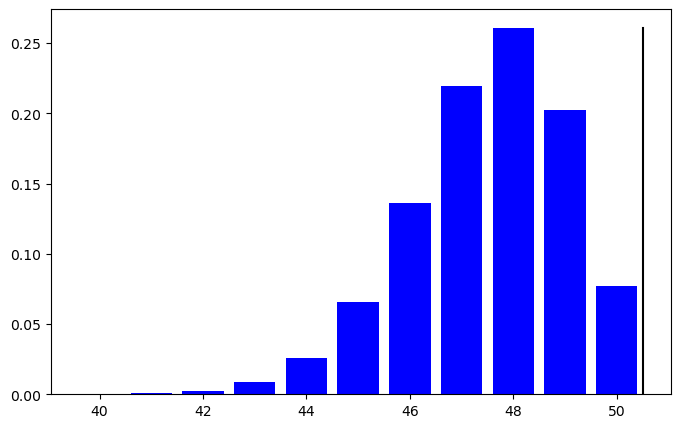

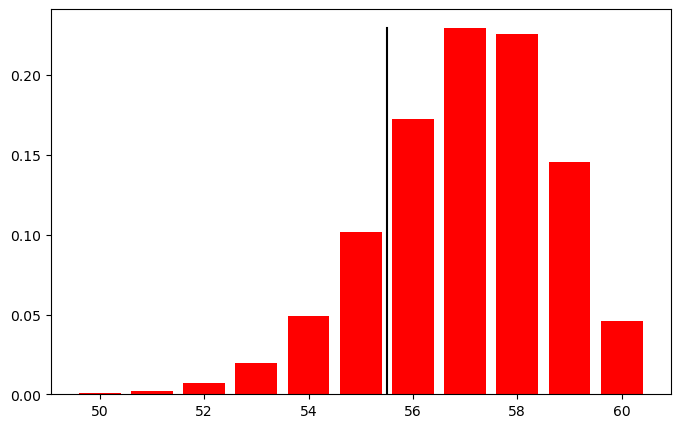

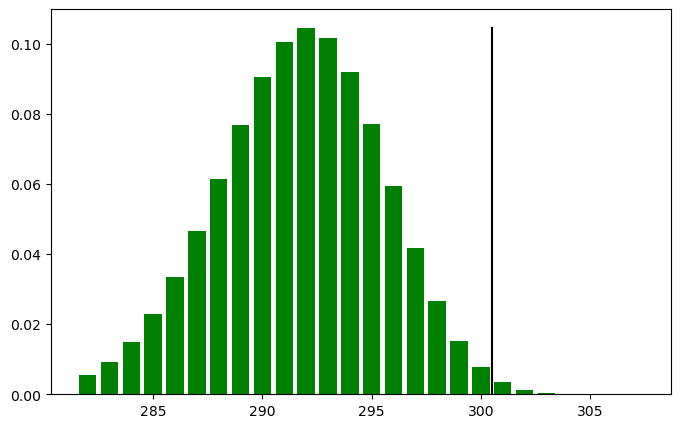

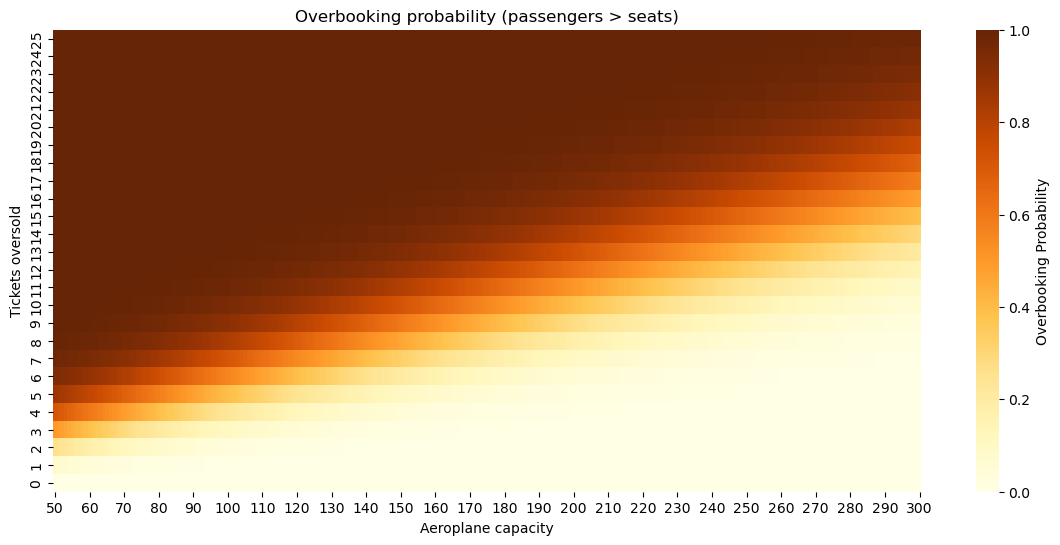

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

# let's plot the binomial pmf for a few scenarios

# here clearly all passengers can fit, we haven't done any overbooking
n = 50 # number of tickets sold  
p = 0.95 
capacity = 50 # aeroplane capacity
x = np.arange(n-10, n + 1)
plt.figure(figsize=(8, 5))
pmf = binom.pmf(x, n, p)
plt.bar(x, binom.pmf(x, n, p), color='blue')
plt.plot([capacity+0.5, capacity+0.5], [0, np.max(pmf)], color='black')
plt.show()

# here we sell more tickets than seats, the integral of the bins *above* the black line
# corresponds to the probability that at least one passenger over capacity shows up
n = 60  # number of tickets sold  
p = 0.95 
capacity = 55 # aeroplane capacity
x = np.arange(n-10, n + 1)
plt.figure(figsize=(8, 5))
pmf = binom.pmf(x, n, p)
plt.bar(x, pmf, color='red')
plt.plot([capacity+0.5, capacity+0.5], [0, np.max(pmf)], color='black')
plt.show()

# a not so random example, you'll see in a moment
n = 307 # number of tickets sold  
p = 0.95 
capacity = 300 # aeroplane capacity
x = np.arange(n-25, n + 1)
plt.figure(figsize=(8, 5))
pmf = binom.pmf(x, n, p)
plt.bar(x, binom.pmf(x, n, p), color='green')
plt.plot([capacity+0.5, capacity+0.5], [0, np.max(pmf)], color='black')
plt.show()

#################################### 

# let's now work the full scale case

capacity = np.arange(50, 300+1)
tickets_oversold = np.arange(25+1)

def cumulative_overbooking_probability(capacity, tickets_oversold, p=0.95):
    npassengers = tickets_oversold + capacity
    prob = binom.cdf(capacity, npassengers, p) # cumulative distribution function *from 0 to capacity!* (check yourself). 
    return 1-prob

X, Y = np.meshgrid(capacity, tickets_oversold)
Z = cumulative_overbooking_probability(X, Y[::-1]) # reverse Y to have increasing values on the Y axis

# plot it!
plt.figure(figsize=(14, 6))
ax = sns.heatmap(Z, yticklabels=tickets_oversold[::-1], xticklabels=10, cmap="YlOrBr", cbar_kws={'label': 'Overbooking Probability'})
ax.set_xticklabels(capacity[::10]) # one every ten
plt.xlabel("Aeroplane capacity")
plt.ylabel("Tickets oversold")
plt.title("Overbooking probability (passengers > seats)")
plt.show()


2. earlier we computed the cumulative probability function $\mathcal{P}(X>C)$.   
   However, now we need to compute the exact PMF (probability _mass_ function, remember, it's a discrete distribution) for each $X_i$ with $i\geq C$ and weight it by either the ticket price, if the airline company got lucky and sold more tickets than seats, or by *minus* twice the ticket price, if the company got unlucky and more passengers than available seats showed up

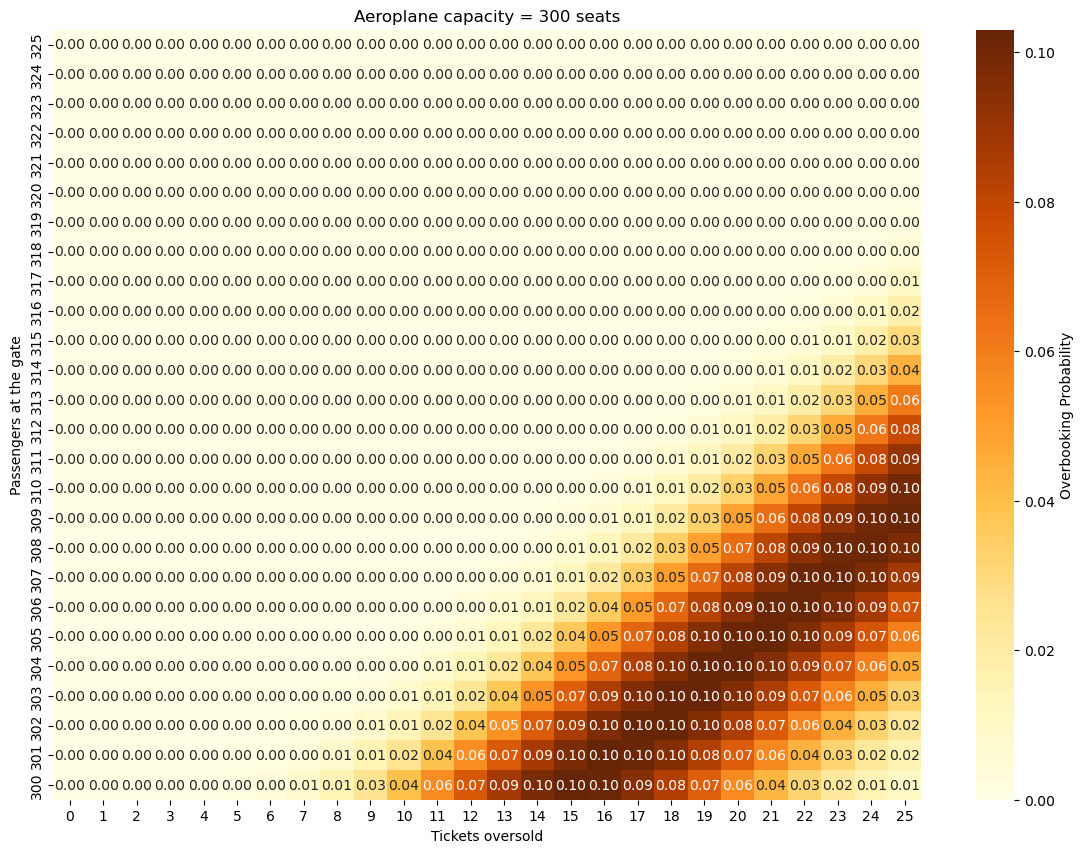

In [3]:
def overbooking_probability(passengers_at_the_gate, capacity, tickets_oversold, p=0.95):
    npassengers = tickets_oversold + capacity
    prob = binom.pmf(passengers_at_the_gate, npassengers, p) 
    return prob

plane_seats = 300

# let's plot this too for a 300 seat aeroplane 
XX, YY = np.meshgrid(plane_seats + tickets_oversold, tickets_oversold) # XX is passengers at the gate, YY number of oversold tickets 
ZZ = overbooking_probability(XX, plane_seats, YY) # reverse Y to have increasing values on the Y axis

# plot it!
plt.figure(figsize=(14, 10))
ax = sns.heatmap(ZZ.T[::-1,:], xticklabels=tickets_oversold, yticklabels=(plane_seats + tickets_oversold)[::-1], annot=True, fmt=".2f", cmap="YlOrBr", cbar_kws={'label': 'Overbooking Probability'})
plt.xlabel("Tickets oversold")
plt.ylabel("Passengers at the gate")
plt.title("Aeroplane capacity = %d seats" %plane_seats)
plt.show()

it is already clear that, for a 300 seat aeroplane, the airline can sell about 7 extra tickets with virtually zero chances to incurr in any refund or claim because of overbooking.

**But what is the optimum?**  

Starting from the matrix above, for each colum we need to computed the total possible money loss, calculated as twice the cost of the ticket per passenger left stranded, weighed by the probability in each cell, do the same for the potential extra profit and then subtract the potential loss from the extra cost and see for which number of oversold tickets it is the largest.

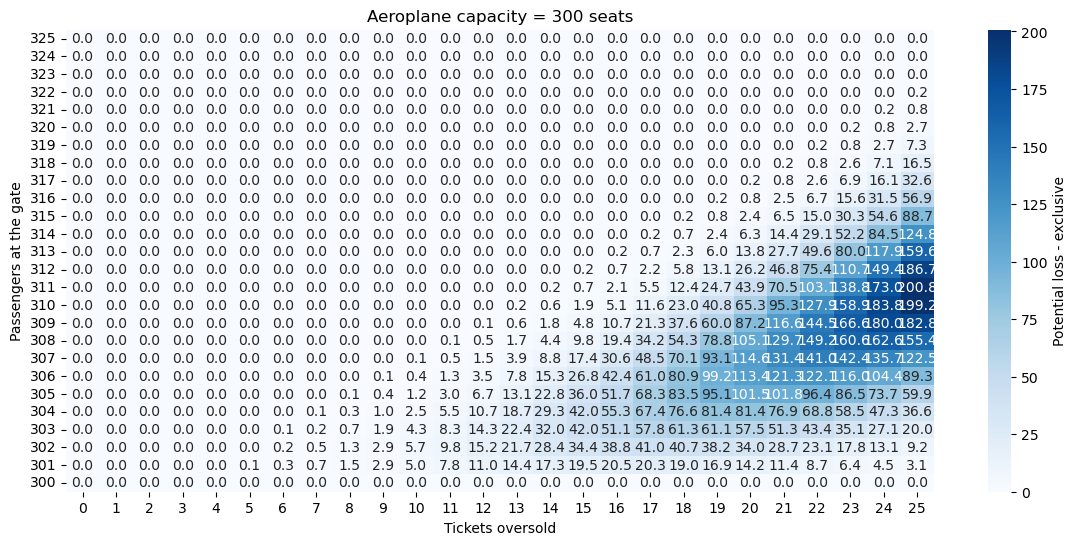

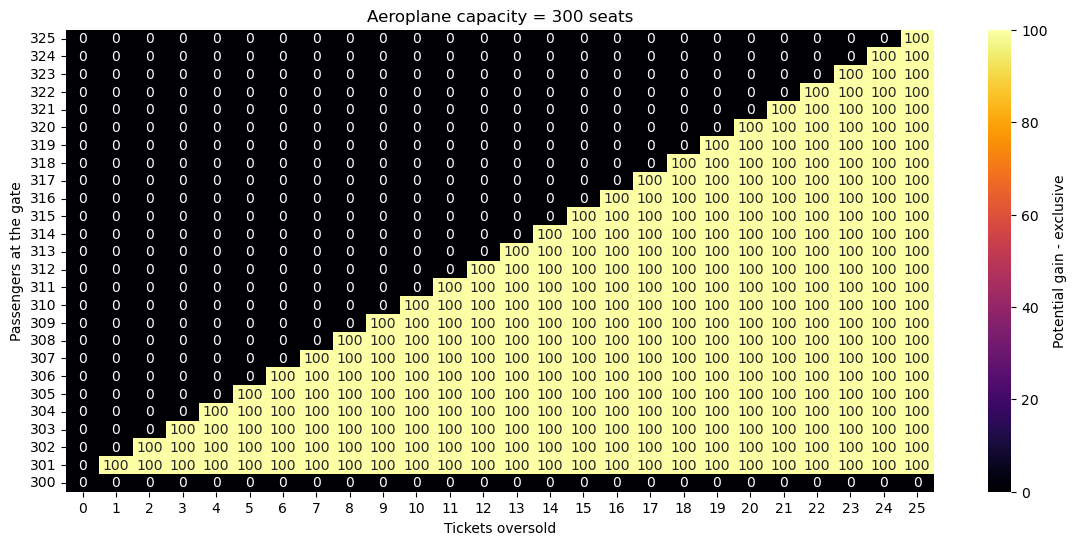

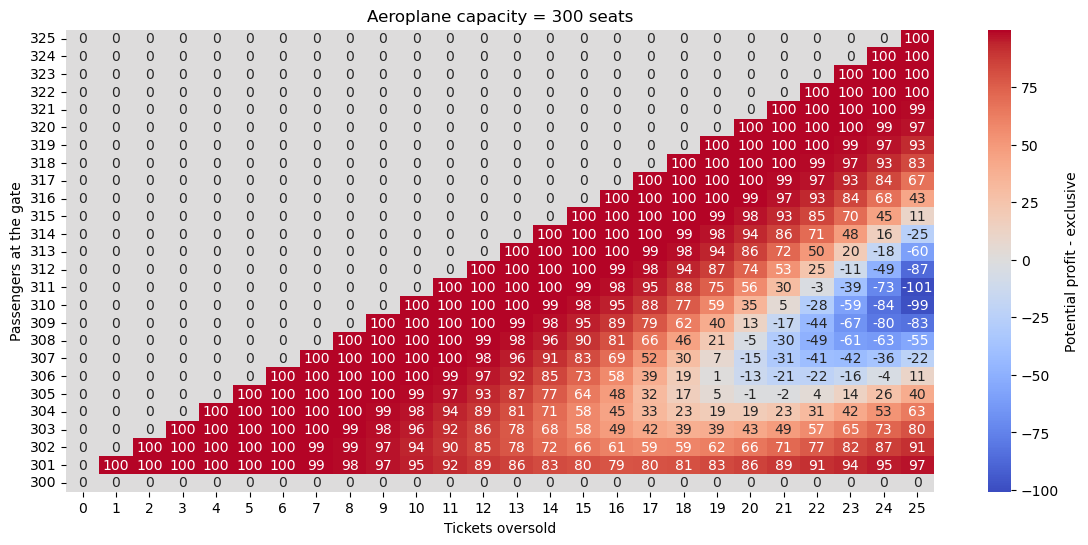

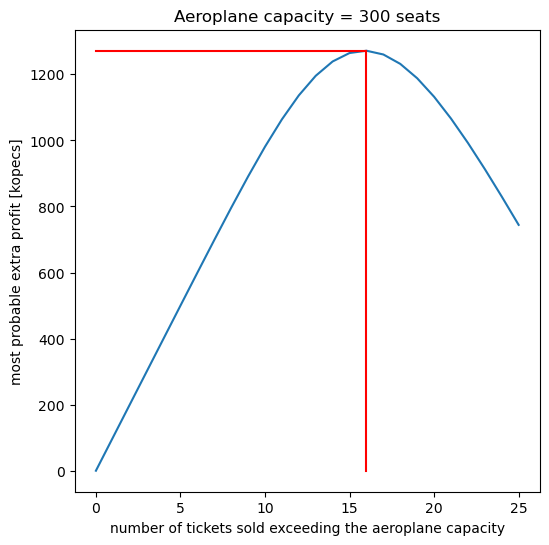

In [4]:
ticket_price = 100. # kopecs 
penalty = 2.

loss = ticket_price * ZZ.T * tickets_oversold[:,None] * penalty
loss = loss[::-1,:] # rotate it as it should be, I suck at this
gain = ticket_price * np.ones(ZZ[:,::-1].shape) * (ZZ[:,::-1]!=0.)
gain[-1,:] = 0.

plt.figure(figsize=(14, 6))
ax = sns.heatmap(loss, yticklabels=plane_seats+tickets_oversold[::-1], cmap="Blues", annot=True, fmt=".1f", cbar_kws={'label': 'Potential loss - exclusive'})
plt.xlabel("Tickets oversold")
plt.ylabel("Passengers at the gate")
plt.title("Aeroplane capacity = %d seats" %plane_seats)
plt.show()

plt.figure(figsize=(14, 6))
ax = sns.heatmap(gain, yticklabels=plane_seats+tickets_oversold[::-1], annot=True, fmt=".0f", cmap="inferno", cbar_kws={'label': 'Potential gain - exclusive'})
plt.xlabel("Tickets oversold")
plt.ylabel("Passengers at the gate")
plt.title("Aeroplane capacity = %d seats" %plane_seats)
plt.show()


profit = gain-loss

plt.figure(figsize=(14, 6))
ax = sns.heatmap(profit, yticklabels=plane_seats+tickets_oversold[::-1], annot=True, fmt=".0f", cmap="coolwarm", center=0, cbar_kws={'label': 'Potential profit - exclusive'})
plt.xlabel("Tickets oversold")
plt.ylabel("Passengers at the gate")
plt.title("Aeroplane capacity = %d seats" %plane_seats)
plt.show()


cumulative_loss = np.cumsum(loss, axis=0)[-1,:]
cumulative_gain = np.cumsum(gain, axis=0)[-1,:]

cumulative_profit = cumulative_gain - cumulative_loss

optimum_idx = np.argmax(cumulative_profit)
optimum = tickets_oversold[optimum_idx]

plt.figure(figsize=(6, 6))
plt.plot(tickets_oversold, cumulative_profit)
plt.plot([optimum, optimum],[0., np.max(cumulative_profit)], color='r')
plt.plot([0., optimum],[np.max(cumulative_profit), np.max(cumulative_profit)], color='r')
plt.xlabel("number of tickets sold exceeding the aeroplane capacity")
plt.ylabel("most probable extra profit [kopecs]")
plt.title("Aeroplane capacity = %d seats" %plane_seats)
plt.show()

For a 300 seat aeroplane and a no-show probability of 5% (assuming that refunding a stranded passenger costs twice as much as the ticket), airlines can make an extra profit of about 1200/(300*100) = 4% by selling 16 more tickets than available seats.

2. bonus: compute this for any number of seats between 50 and 300

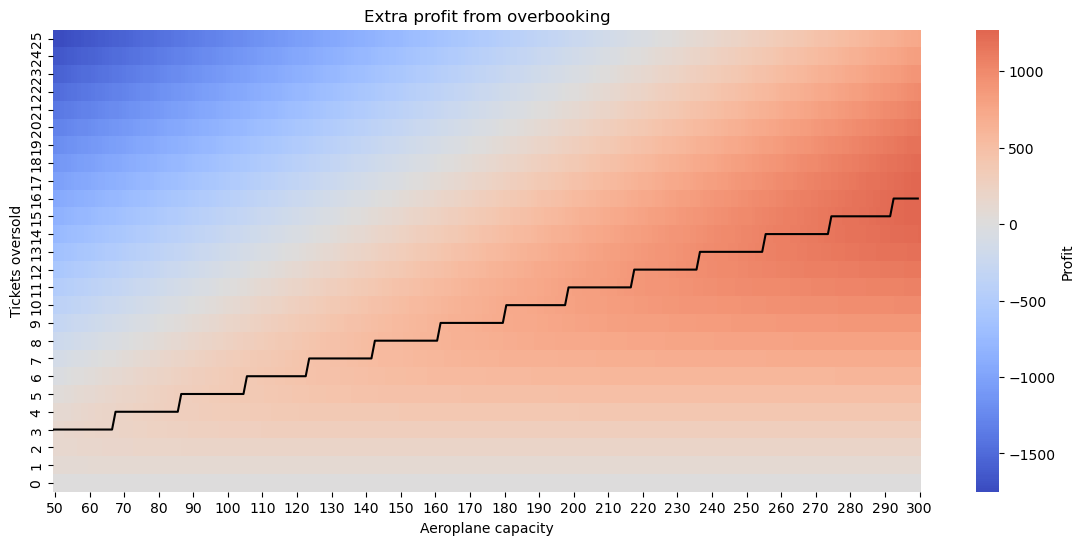

In [5]:
results = np.zeros((len(capacity), len(tickets_oversold)))

for ii, plane_seats in enumerate(capacity):
    XX, YY = np.meshgrid(plane_seats + tickets_oversold, tickets_oversold) # XX is passengers at the gate, YY number of oversold tickets 
    ZZ = overbooking_probability(XX, plane_seats, YY) # reverse Y to have increasing values on the Y axis
    
    loss = ticket_price * ZZ.T * tickets_oversold[:,None] * penalty
    loss = loss[::-1,:] # rotate it as it should be, I suck at this
    
    gain = ticket_price * np.ones(ZZ[:,::-1].shape) * (ZZ[:,::-1]!=0.)
    gain[-1,:] = 0.
    
    cumulative_loss = np.cumsum(loss, axis=0)[-1,:]
    cumulative_gain = np.cumsum(gain, axis=0)[-1,:]

    cumulative_profit = cumulative_gain - cumulative_loss

    optimum_idx = np.argmax(cumulative_profit)
    optimum = tickets_oversold[optimum_idx]

    results[ii, :] = cumulative_profit

plt.figure(figsize=(14, 6))
#ax = sns.heatmap(results.T[::-1,:], xticklabels=capacity, yticklabels=tickets_oversold[::-1],  cmap="Blues", annot=True, fmt=".1f", cbar_kws={'label': 'Profit'})
ax = sns.heatmap(results.T[::-1,:], xticklabels=10, yticklabels=tickets_oversold[::-1], cmap="coolwarm", center=0, cbar_kws={'label': 'Profit'})
ax.set_xticklabels(capacity[::10]) # one every ten
plt.xlabel("Aeroplane capacity")
plt.ylabel("Tickets oversold")
plt.title("Extra profit from overbooking")

# Find row indices of column-wise maximums
row_indices = np.argmax(results.T[::-1,:], axis=0)
plt.plot(np.arange(len(capacity)),row_indices+0.5, color='black')
plt.show()

# 2) Poisson distribution

1. for a discrete random variable $x$ that follows the Poisson distribution $\mathcal{P}(x) = \frac{\mu^x}{x!}e^{-\mu}$, show that the parameter $\mu$ represents both the means and the variance
3. a particle detector used to measure the activity of a radioactive source has a dead time of 1 $\mu s$. That is, after a particle has been recorded by the detector, the detector remains blind and unable to detect other particle for a duration of 1 $\mu s$. Plot the probability that a particle impinging on the detector after a positive count would end up in a dead time window (and not be detected) as a function of the incoming flux particle/second.
4. The detector measure a count rate of 0.3 MHz. Compute the actual flux of the radioactive source, considering the detector efficiency of 60% and a deadtime of 1 $\mu s$

## Solution

1. Using the definition of the expectation value (mean) we get
$$
E(x) = \sum_{k=0}^{\infty} k \mathcal{P}(k) = \sum_{k=0}^{\infty} k \frac{\mu^k e^{-\mu}}{k!}
$$
then, since for $k = 0$ the first term of the sum is null, we can change the starting index from 0 to 1
$$
E(x) = \sum_{k=1}^{\infty} k \frac{\mu^k e^{-\mu}}{k!}
$$
now, let's rewrite $\mu^k = \mu \cdot \mu^{k-1}$ and $k! = k(k-1)!$, and take $e^{-\mu}$ and $\mu$ out of the sum
$$
E(x) = e^{-\mu}\cdot \mu \cdot \sum_{k=1}^{\infty} \cancel{k} \frac{\mu^{k-1}}{\cancel{k}(k-1)!}
$$
if we change variable $t = k-1$, the sum becomes 
$$
\sum_{t=0}^{\infty} \frac{\mu^{t}}{t!} = e^{\mu}
$$
which is the Taylor expansion of $e^{\mu}$. Finally, $E(x) = e^{-\mu} \cdot \mu \cdot e^{\mu} = \mu$  
We take a slightly more convoluted route to demonstrate that the variance too corresponds to $\mu$, first we compute the moment of the second order
$$
E(x^2) = \sum_{k=0}^{\infty} k^2 \frac{\mu^k e^{-\mu}}{k!} = e^{-\mu} \cdot \mu \cdot \sum_{k=0}^{\infty} \cancel{k}k \frac{\mu^{k-1}}{\cancel{k}(k-1)!}
$$
notice again that the term for $k=0$ is null, therefore we're left with (change of starting index)
$$
E(x^2) = e^{-\mu} \cdot \mu \cdot \sum_{k=1}^{\infty}k \frac{\mu^{k-1}}{(k-1)!}
$$
let's write $k = (k-1) + 1$ to obtain
$$
E(x^2) = e^{-\mu} \cdot \mu \cdot \left[ \sum_{k=1}^{\infty}(k-1) \frac{\mu^{k-1}}{(k-1)!} + \sum_{k=1}^{\infty} \frac{\mu^{k-1}}{(k-1)!} \right]
$$
again, change of index $t = k-1$, therefore $t$ starts from 0, and we distribute the factor $e^{-\mu}$ to the two terms inside the square bracket
$$
E(x^2) = \mu \cdot \left[ \sum_{t=0}^{\infty}t \frac{\mu^t}{t!}\cdot e^{-\mu} + \sum_{t=0}^{\infty} \frac{\mu^t}{t!}\cdot e^{-\mu} \right]
$$
The first term in the quare bracket is simply $\mu$, as we have demonstrated before, whereas the second term gives $e^\mu$. Finally
$$
E(x^2) = \mu \cdot \left[ \mu + 1 \right] = \mu^2 + \mu
$$
Not finished yet... Now let's plug $E(x)$ and $E(x^2)$ in the definition of variance $\sigma^2 = E(x^2) - E(x)^2 = \cancel{\mu^2} + \mu \cancel{-\mu^2} = \mu$

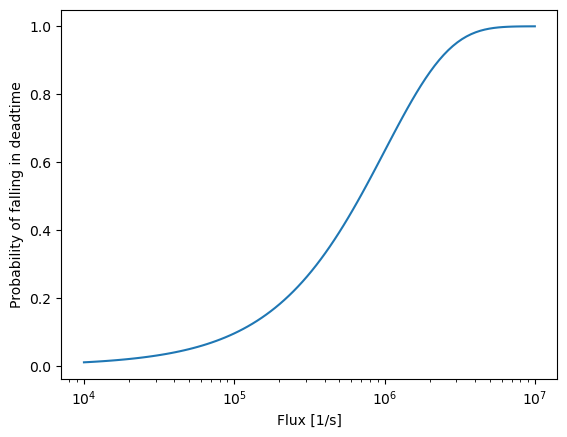

In [6]:
from scipy.stats import poisson

deadtime = 1e-6
flux = np.logspace(4, 7, 100)

# mean of the poisson is flux * deadtime
# the probability of having at least one particle produced by the radioactive source in a time spac equal to deadtime is
# equal to 1 minus the probability of producing none
prob_produced_during_deadtime = 1 - poisson.pmf(0, flux * deadtime)

plt.plot(flux, prob_produced_during_deadtime)
plt.xlabel('Flux [1/s]')
plt.ylabel('Probability of falling in deadtime')
plt.xscale('log')
plt.show()

Notice that the detector isn't completely blind even for flux of 1 MHz corresponding to the inverse of deadtime.

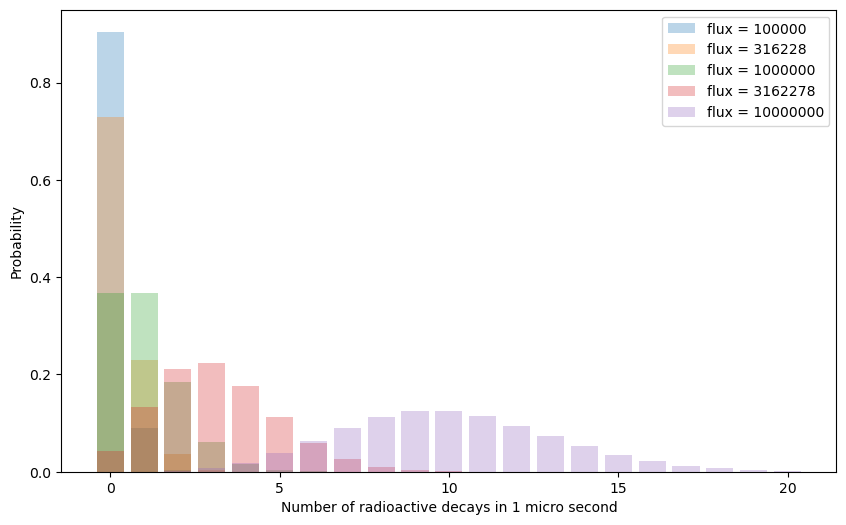

In [7]:
# to better understand we can plot the poisson distribution of number of particles in a time window of 1e-6 seconds for different decay rates
flux = deadtime*np.logspace(5, 7, 5)
nparticles = np.linspace(0, 20, 21)

plt.figure(figsize=(10, 6))

for iflux in flux:
    pmf = poisson.pmf(nparticles, iflux)
    plt.bar(nparticles, pmf, label=f'flux = {iflux/deadtime:.0f}', alpha=0.3)

# Add labels and title
plt.xlabel('Number of radioactive decays in 1 micro second')
plt.ylabel('Probability')
plt.legend()

# Show the plot
plt.show()

To derive the relation between the the measured rate and the deadtime, let's start from computing the total dead time
$$\rm{total~deadtime} = N_{\rm{meas}} \cdot \rm{deadtime}$$ 
from which, we can calculate the fraction of time that the detector was active over the full data taking period $T$
$$\frac{T - N_{\rm{meas}}\cdot \rm{deadtime}}{T} = 1 - R_{\rm{meas}}\cdot \rm{deadtime}$$
now let's write the number of measured counts as 
$$N_{\rm{meas}} = N_{\rm{true}} \times \left[1-R_{\rm{meas}} \cdot \rm{deadtime} \right] \cdot \epsilon$$
where $\epsilon$ is the detection efficiency

Now divide by the total time $T$ to obtain $R_{\rm{meas}} = R_{\rm{true}} \times \left[1-R_{\rm{meas}} \cdot \rm{deadtime} \right] \cdot \epsilon$ whcih can be solved for $R_{\rm{true}}$
$$R_{\rm{true}} = \frac{R_{\rm{meas}}}{\left[1-R_{\rm{meas}} \cdot \rm{deadtime} \right]\cdot \epsilon}$$

Text(0.5, 1.0, 'Rate and deadtime')

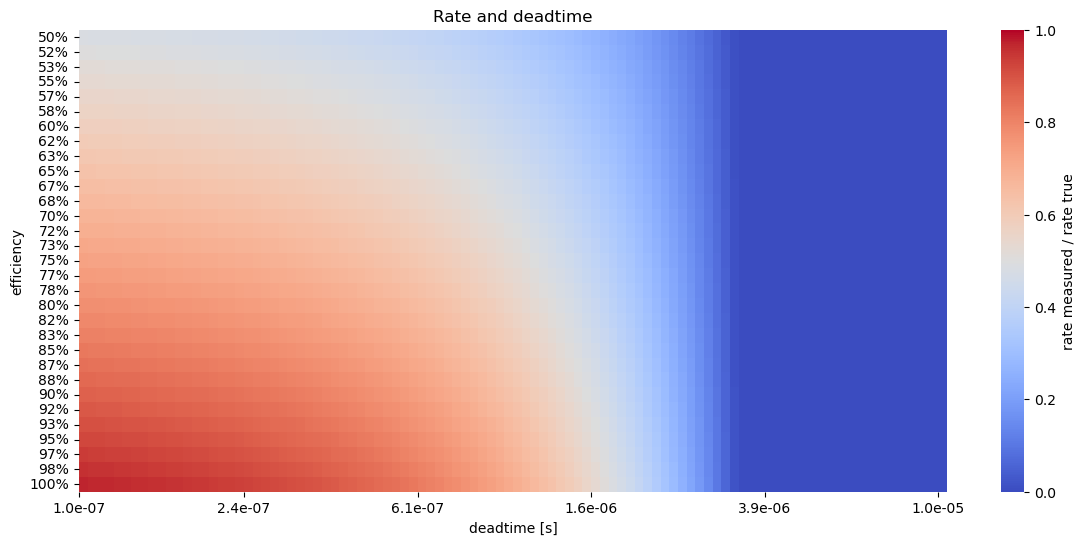

In [8]:
from matplotlib.colors import Normalize

rate_measured = 3e5
deadtime = np.logspace(-7, -5, 100)
eff = np.linspace(0.5, 1., 31)

X, Y = np.meshgrid(deadtime, eff)

rate_true = rate_measured / (1-rate_measured*X) / Y

ratio = rate_measured/rate_true

plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    ratio, 
    cmap="coolwarm", 
    xticklabels=5, 
    cbar_kws={'label': 'rate measured / rate true'}, 
    norm=Normalize(vmin=0, vmax=1),
)
xtick_positions = np.linspace(0, len(deadtime) - 1, 6, dtype=int)
ax.set_xticks(xtick_positions)
ax.set_xticklabels([f"{deadtime[i]:.1e}" for i in xtick_positions])
ax.set_yticklabels([f"{100.*eff[i]:.0f}%" for i in range(len(eff))])  # Convert to percentage

plt.xlabel("deadtime [s]")
plt.ylabel("efficiency")
plt.title("Rate and deadtime")

# 3) Central Limit Theorem (CLT)

For an excellent animated explanation, watch this video
https://www.youtube.com/watch?v=zeJD6dqJ5lo

1. An experiment consists of rolling 5 dice and then noting down the sum of the 5 outcomes.
   Repeat the experiment 1, 10, 100, 1000, and 10000 times and for each number of repetitions, plot the obtained sum of outcomes in an histogram. Superimpose to each histogram the normal distribution with mean and width parameters predicted by the central limit theorem
3. for this variation, use unfair dice, that is the probability of their outcomes isn't 1/6 for each of the 6 digits, but [0.37, 0.16, 0.10, 0.07, 0.11, 0.19] for [1, 2, 3, 4, 5, 6] respectively. Start with rolling 10 dice up to 100000 repetitions
2. with the same unfair dice, roll only 2 dice, again for up to 100000 repetitions. Does CLT work?
3. now roll 6 *different* unfair dice, for each dice use a permutation of the distribution given above [0.37, 0.16, 0.10, 0.07, 0.11, 0.19] (no repetitions). Does CLT work?

## solution

0 1.0
1 10.0
2 100.0
3 1000.0
4 10000.0


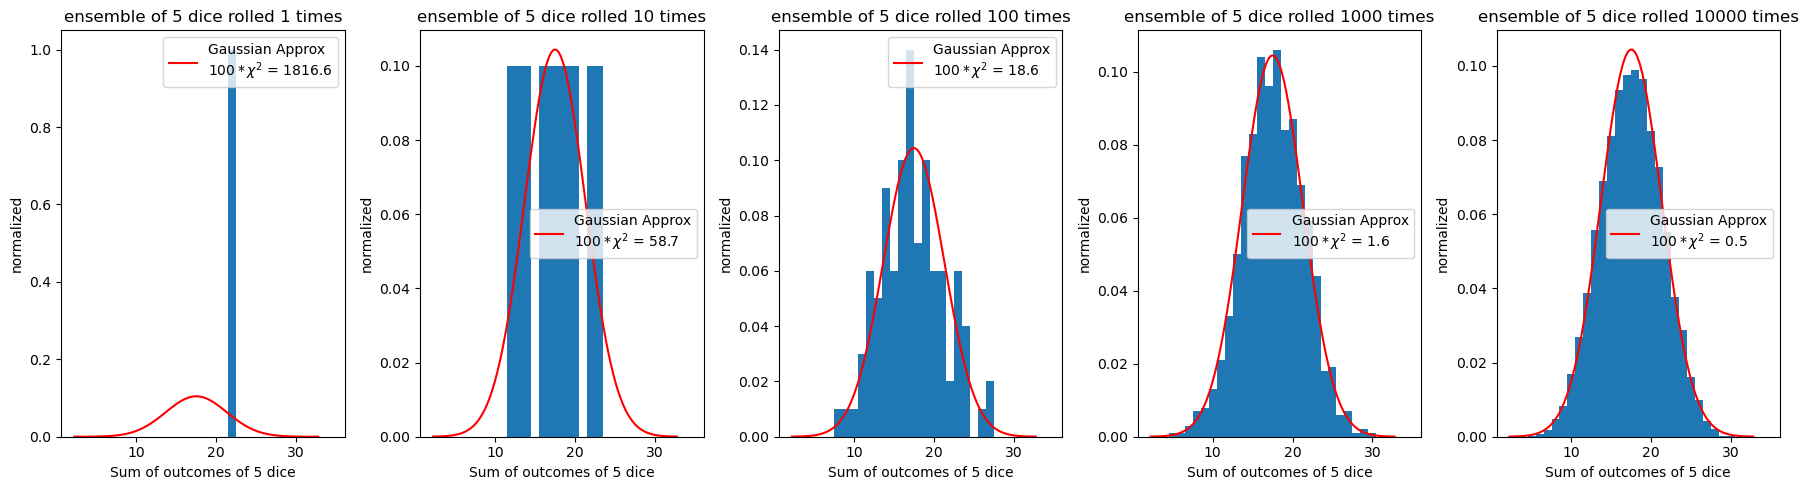

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# fix random seed for reproducibility
np.random.seed(42)

# number of dice
ndice = 5

# number of faces 
nfaces = 6

# sumber of repetitions of the experiment "rolling ndice"
nevents = np.logspace(0, 4, 5)

# histogram binning
bins = np.linspace(ndice*1, ndice*(nfaces+1), ndice*nfaces + 1) - 0.5 # -0.5 offset needed to have centered bins

# mean outcome of a nfaces die roll
mean_die = np.mean(np.linspace(1, nfaces, nfaces))

# variance of outcome of a nfaces die roll
mean_var = np.var(np.linspace(1, nfaces, nfaces))

# generator
generator = lambda N : np.random.randint(1, nfaces+1, (int(N), ndice))


def clt(ndice, nfaces, nevents, bins, mean_die, mean_var, generator):
    
    # Create plots for each event count
    fig, axes = plt.subplots(1, len(nevents), figsize=(18, 5))
    
    for idx, N in enumerate(nevents):
    
        print(idx, N)

        N = int(N)
        
        # generate as many datasets as means, with nevents each
        #datasets = np.random.randint(1, nfaces+1, (int(N), ndice)) # ndice rolled N times. 6 faces per die
        datasets = generator(N)
        
        # for each experiment of "rolling ndice", sum the outcomes of each 
        sums = datasets.sum(axis=1)
    
        # Plot histogram of the sum of uniform variables
        counts, bin_edges, _ = axes[idx].hist(sums, bins=bins, density=True, alpha=1.0)

        # Compute bin centers
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  

        # CLT Gaussian distribution parameters
        mean_gaussian = ndice * mean_die
        std_gaussian = np.sqrt(ndice * mean_var)
        
        # Overlay the theoretical Gaussian distribution
        x = np.linspace(mean_gaussian - 4*std_gaussian, mean_gaussian + 4*std_gaussian, 100)
        y = norm.pdf(x, mean_gaussian, std_gaussian)

        # Compute chi-squared statistic
        gaus_at_bin_centers = norm.pdf(bin_centers, mean_gaussian, std_gaussian)
        chi2 = np.sum((counts - gaus_at_bin_centers) ** 2 / gaus_at_bin_centers)

        # plot gaus
        axes[idx].plot(x, y, 'r-', label=f"Gaussian Approx\n$100*\chi^2$ = {100*chi2:.1f}")

        # plot embellishments
        axes[idx].set_title(f'ensemble of {ndice} dice rolled {N:.0f} times')
        axes[idx].set_xlabel(f'Sum of outcomes of {ndice} dice')
        axes[idx].set_ylabel('normalized')
        axes[idx].legend()
        
    plt.tight_layout()
    plt.show()

#####################
clt(ndice, nfaces, nevents, bins, mean_die, mean_var, generator)

with more repetitions of the experiment, the oberved distribution gets closer and closer to the gaussian curve predicted by the CLT.  
The $\chi^2$ test statistics (that will be discussed later in lectures) improves.

let's not try with only 10 unfair dice, still all dice have the same pmf

0 1.0
1 10.0
2 100.0
3 1000.0
4 10000.0
5 100000.0


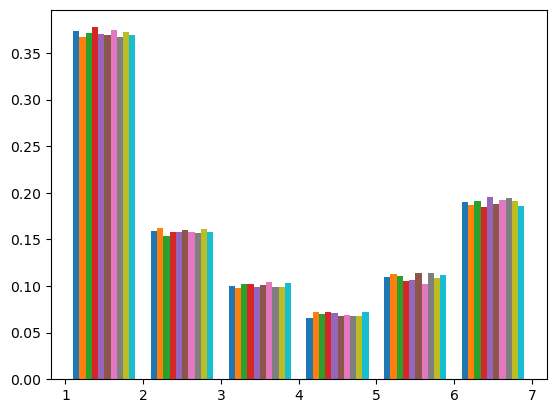

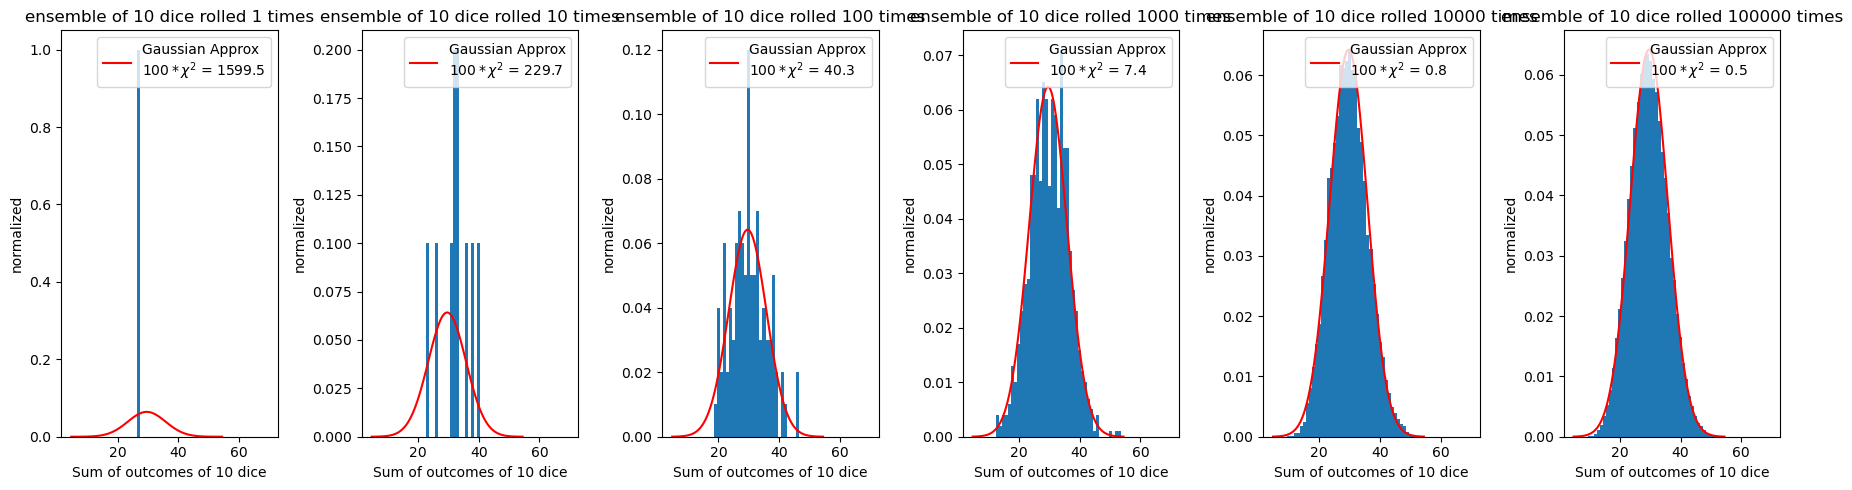

In [10]:
ndice = 10

# die faces
values = np.array([1, 2, 3, 4, 5, 6])

# unfair die
probs = np.array([0.37, 0.16, 0.10, 0.07, 0.11, 0.19])

# mean unfair die (weighed)
mean_die = np.average(values, weights=probs)

# variance of unfair die (weighed)
mean_var = np.sum(probs * (values - mean_die) ** 2) / np.sum(probs)

# generator
generator = lambda N : np.random.choice(values, size=(int(N), ndice), p=probs)

# number of repetitions of the experiment "rolling ndice"
nevents = np.logspace(0, 5, 6)

# histogram binning
bins = np.linspace(ndice*1, ndice*(nfaces+1), ndice*nfaces + 1) - 0.5 # -0.5 offset needed to have centered bins

# plot the pmf (probability mass function) of the unfair die
plt.clf()
plt.hist(generator(10000), bins=[1,2,3,4,5,6,7], density=True)

#####################
clt(ndice, nfaces, nevents, bins, mean_die, mean_var, generator)


even with draws from non uniform distributions, the CLT works

0 1.0
1 10.0
2 100.0
3 1000.0
4 10000.0
5 100000.0


<Figure size 640x480 with 0 Axes>

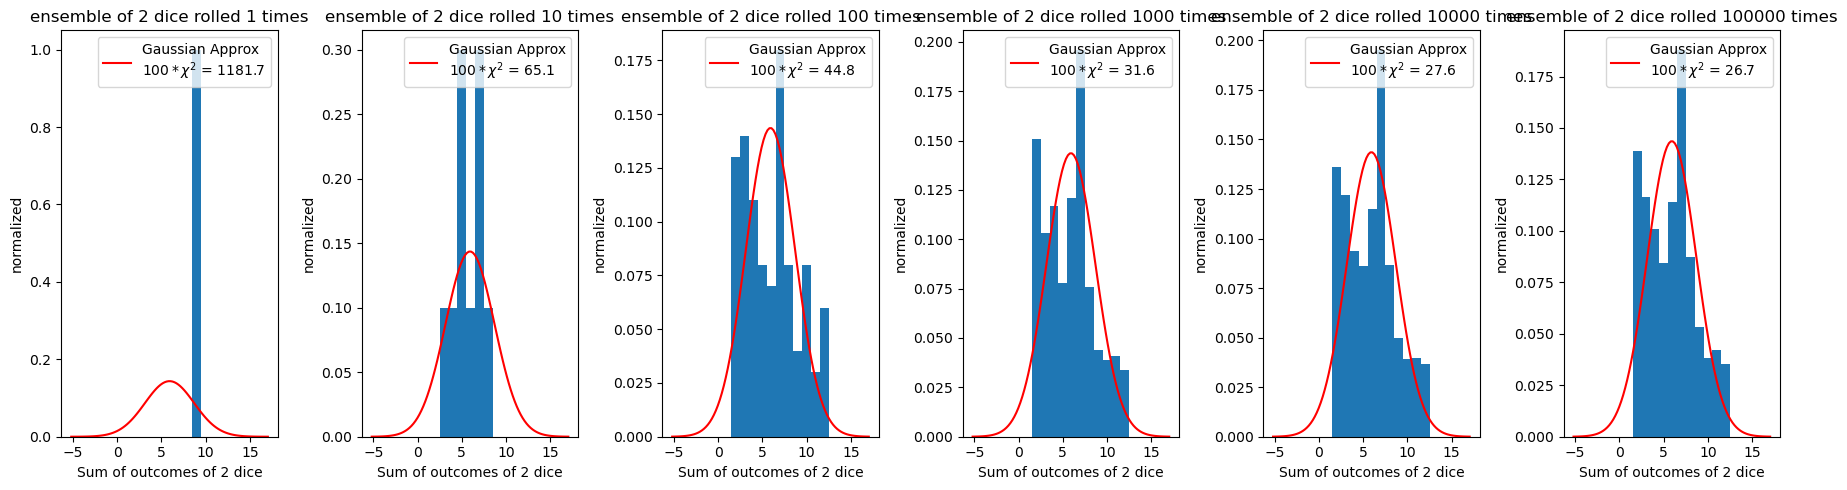

In [11]:
ndice = 2

# number of repetitions of the experiment "rolling ndice"
nevents = np.logspace(0, 5, 6)

# histogram binning
bins = np.linspace(ndice*1, ndice*(nfaces+1), ndice*nfaces + 1) - 0.5 # -0.5 offset needed to have centered bins

#####################
plt.clf()
clt(ndice, nfaces, nevents, bins, mean_die, mean_var, generator)

with too few dice, the CLT break. Think about why, which conditios aren't met

0 1.0
1 10.0
2 100.0
3 1000.0
4 10000.0
5 100000.0


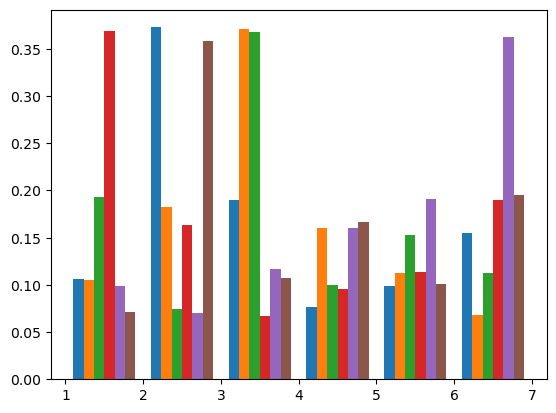

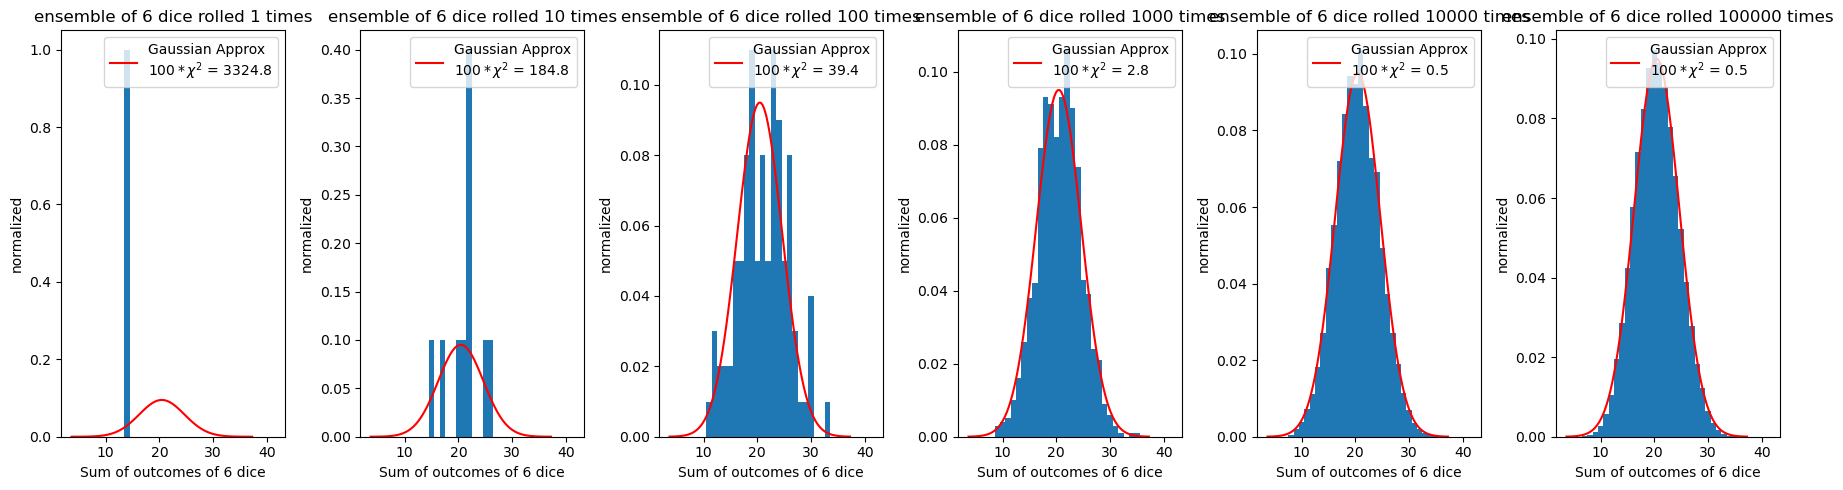

In [11]:
ndice = 6

# number of repetitions of the experiment "rolling ndice"
nevents = np.logspace(0, 5, 6)

# histogram binning
bins = np.linspace(ndice*1, ndice*(nfaces+1), ndice*nfaces + 1) - 0.5 # -0.5 offset needed to have centered bins

# probabilities
probs = np.array([0.37, 0.16, 0.10, 0.07, 0.11, 0.19])
# six different permutations
probs_perm = [np.random.permutation(probs) for _ in range(ndice)]

# means and variances change too!

# mean unfair die (weighed)
mean_die = np.mean([np.average(values, weights=probs_perm[i]) for i in range(ndice)])

# variance of unfair die (weighed)
mean_var = np.mean([np.sum(probs_perm[i] * (values - mean_die) ** 2) / np.sum(probs_perm[i]) for i in range(ndice)])


# generator
def generator(N):
    N = int(N)
    samples = np.zeros((N, ndice), dtype=int)
    for col in range(ndice):
        samples[:, col] = np.random.choice(values, size=N, p=probs_perm[col])
    return samples

#####################

# plot the pmf (probability mass function) of the unfair die
plt.clf()
plt.hist(generator(10000), bins=[1,2,3,4,5,6,7], density=True)

clt(ndice, nfaces, nevents, bins, mean_die, mean_var, generator)

even if each die is drawn from a different distribution, CLT works!

# 4) Summary statistics

In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from scipy.stats import multivariate_normal
import numpy as np

def generate_dataset(N, seed=42):
    np.random.seed(seed)
    # Define mean vector (center of the distribution)
    mean = [1, -0.5, 1.2]
    # Define covariance matrix (controls relationships between features)
    cov = [
        [3,     -0.8,  1.2],
        [-0.8,  1.5,   0.5],
        [1.2,   0.5,   2]
    ]
    # Sample N points from the multivariate normal distribution
    X = np.random.multivariate_normal(mean, cov, size=N)
    X2, Y = make_moons(n_samples=N, noise=0.05, random_state=seed)
    X3 = np.random.poisson(1, size=N) #+ np.random.normal(0, 0.3, size=N)
    
    data = np.concatenate([X, X2, X3[:,None]], axis=1)
    return data

In [13]:
N = 10000
X = generate_dataset(N, seed=42)

# for convenience, convert into pandas dataframe to have named columns
import pandas as pd
columns = ["temperature", "pression", "position", "speed", "acceleration", "number_of_particles"]
X = pd.DataFrame(X, columns=columns)

You have a dataset consisting of multiple observations of 6 quantities, measured in a lab experiment: temperature, pression, position, speed, acceleration, number of particles.

- Each "row" in the dataset corresponds to a different observation.
- Each "column" in the dataset corresponds to a different features or measurement of your observation.

**Your goal for this exercise is to compute the summary statistics for each of the quantities measured in the experiment**:
- How the features are distributed?
    - Compute the mean and the standard deviation of each feature
    - Compute the median and the mode of the distributions "by hand", then try with python libraries methods.
    - Compute the quantiles of each feature
      
- How they are correlated? Compute the covariance matrix of the features and the correlation.
- Compute higher order momenta of the distributions.
- Before doing any histogram, how do you expect the numbers are distributed? Do you think they are gaussian or having a different distribution?  (_don't look too close to the dataset generating code_ ;) )

### Mean and standard deviation

#### Manual computation:

In [14]:
mean = np.sum(X, axis=0) / N

std = np.sqrt( np.sum( (X - mean)**2, axis=0) / (N-1))

print(f"{'Mean:':<15} {mean}")
print(f"{'Std:':<15} {std}")

# alternatively, one can use the relation bewteen variance, mean and mean of squares to compute the standard deviation
mean2 = np.sum(X**2, axis=0) / N

variance = mean2 - mean**2
print(f"{'sqrt(Variance):':<15} {np.sqrt(variance)}")

Mean:           temperature            1.009742
pression              -0.505808
position               1.203833
speed                  0.500574
acceleration           0.249729
number_of_particles    1.001700
dtype: float64
Std:            temperature            1.734621
pression               1.229628
position               1.413894
speed                  0.867398
acceleration           0.496087
number_of_particles    1.002895
dtype: float64
sqrt(Variance): temperature            1.734534
pression               1.229567
position               1.413823
speed                  0.867355
acceleration           0.496062
number_of_particles    1.002845
dtype: float64


#### Python libs computation:

In [15]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

print(f"{'Mean:':<15} {mean}")
print(f"{'Std:':<15} {std}")

Mean:           temperature            1.009742
pression              -0.505808
position               1.203833
speed                  0.500574
acceleration           0.249729
number_of_particles    1.001700
dtype: float64
Std:            temperature            1.734534
pression               1.229567
position               1.413823
speed                  0.867355
acceleration           0.496062
number_of_particles    1.002845
dtype: float64


### Median and Mode

_The median of a set of numbers is the value separating the higher half from the lower half_  

Question: which quantile does it correspond to?  

#### Median manual computation:

In [16]:
#the median function, taking a list/array as input
def median(lst):
    n = len(lst)
    if n < 1:
            return None # too few entries to split the array into equally populater parts
    if n % 2 == 1: # operator "%" modulus, returns the remainder of the division. Here you check if the length of the array is ODD
            return sorted(lst)[n//2] # operator "//" floor division, divides and rounds DOWN to the closest integer 
    else: # if the length of the array is EVEN, take the mean of the two entries closest to its belly
            return sum(sorted(lst)[n//2-1:n//2+1])/2.0

for icol in columns:
    x = X[icol]
    xsorted = np.sort(x, axis=0)
    print(f"{'Median for feature:'} {icol:<20} {median(xsorted):<10}")

Median for feature: temperature          1.0180245690183316
Median for feature: pression             -0.5029127989588167
Median for feature: position             1.1945138833325277
Median for feature: speed                0.5010478249876362
Median for feature: acceleration         0.24677977412629765
Median for feature: number_of_particles  1.0       


#### Mode computation: 

We need to find the value tha occurs with the maximum probability.   

Since _most_ of the observables in our dataset can take continuous values, a given value will hardly be repeated more than once in most cases.  

Therefore, we need to "discretize" our sets in small intervals of constant size that can contain a sufficient number of entries.  
If these sounds like _histogram bins_ it's because ... they are!

But first, let's find the mode manually

In [17]:
def find_mode(x, nbins=100):
    xmin, xmax = np.min(x), np.max(x)
    bin = (xmax-xmin)/nbins
    max_bin = -1
    max_value = -1
    for i in range(nbins-1):
        interval =  np.sum((x>= (xmin+bin*i)) & (x<(xmin+bin*i+1)))
        if interval > max_value:
            max_bin = i
            max_value = interval
    # We return the central value of the bin where we found the maximum
    return (xmin+max_bin*bin + bin/2)

In [18]:
for icol in columns:
    x = X[icol]
    mode = find_mode(x, nbins=100)
    print(f"{'Mode for feature:'} {icol:<20} {mode:<10}")

Mode for feature: temperature          0.8497582391069235
Mode for feature: pression             -0.9302523181594139
Mode for feature: position             0.7221052784959774
Mode for feature: speed                0.005482604227283874
Mode for feature: acceleration         -0.5177912010076265
Mode for feature: number_of_particles  0.04      


Let's now use some python libs, starting with ... histograms!

Mode for feature: temperature          1.4546568394263133
Mode for feature: pression             -0.7440484930620483
Mode for feature: position             1.0216740876553274
Mode for feature: speed                0.9684274080919264
Mode for feature: acceleration         -0.42853132865152777
Mode for feature: number_of_particles  0.04      


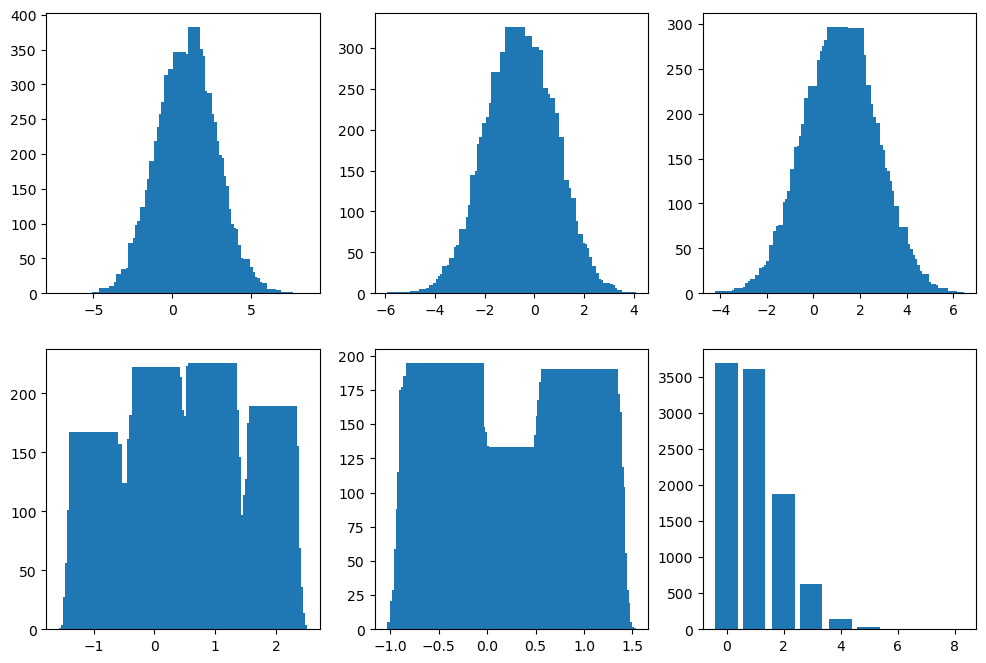

In [19]:
# prepare for plotting too
import matplotlib.pyplot as plt

# create as many subfigures as columns
# 6 columns in 2 rows x 3 columns (pun not intended)
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

for ii, icol in enumerate(columns):
    x = X[icol]
    counts, bins = np.histogram(x, bins=100)  # 100 bins *seems* a reasonable choice, given we have 10k events in the dataset
    axs[ii//3, ii%3].bar(bins[:-1], counts)
    mode_index = np.argmax(counts)  # *index* of the bin with the largest counts
    mode = (bins[mode_index] + bins[mode_index + 1]) / 2.  # find bin center
    print(f"{'Mode for feature:'} {icol:<20} {mode:<10}")

### Quantiles

Compute the quantiles of all the features.

In [20]:
Q = np.quantile(X, q=np.linspace(0, 1, 10), axis=0).T # why transposed?
print(Q)

[[-6.78708659 -1.09871587 -0.31226937  0.25159733  0.76822134  1.27625781
   1.7351962   2.32865067  3.09418146  8.33537842]
 [-5.53879699 -1.9946644  -1.45114385 -1.03558816 -0.68209695 -0.33113207
   0.02835699  0.45401656  0.99244638  3.77139427]
 [-3.82135499 -0.52652481  0.10781353  0.61052534  1.00705569  1.39786582
   1.80776789  2.27842082  2.94200782  6.16427198]
 [-1.17329466 -0.76615336 -0.17080387  0.0983737   0.34969068  0.65256802
   0.9028645   1.17426021  1.7622755   2.14720467]
 [-0.63382904 -0.42933974 -0.26224376 -0.01329712  0.16330307  0.3336698
   0.51233325  0.76496774  0.92997895  1.15136841]
 [ 0.          0.          0.          0.          1.          1.
   1.          2.          2.          8.        ]]


### Covariance and correlation

Compute and plot the covariance matrix of the dataset.  
Even before coding, what is its shape?

1. compute it manually using the definition given during lectures
2. compute it using `numpy` tools 
3. plot it


$$cov_{x_i,x_j} = \frac{1}{N-1} \sum_{k=0}^N ({x_{i,k} - <x_i>}) ({x_{j,k} - <x_j>})$$

where $i$ and $j$ represent one of the quantities of the events in the dataset, i.e. (temperature, pression, position, speed, acceleration, number_of_particles), $k$ is the event index that runs from to number of events, and $<x_i>$ and $<x_j>$ are the expectation values (the means) of the various quantities.

We expect to build a 6x6 symmetric matrix

In [21]:
# let's compute it manually

# first we need the array of the means of all columns
mean = np.mean(X, axis=0)

# then "center" the dataset by removing the mean
centred = X - mean

# voila the covariance matrix
cov = centred.T @ centred / (N-1) # alternative notation X.T.dot(X)/(N-1)

print(cov)

                     temperature  pression  position     speed  acceleration  \
temperature             3.008909 -0.835309  1.209929 -0.019162      0.006784   
pression               -0.835309  1.511986  0.481052  0.001429     -0.003396   
position                1.209929  0.481052  1.999096 -0.001689      0.003061   
speed                  -0.019162  0.001429 -0.001689  0.752380     -0.192323   
acceleration            0.006784 -0.003396  0.003061 -0.192323      0.246102   
number_of_particles     0.009968 -0.006512 -0.000472 -0.000057      0.000445   

                     number_of_particles  
temperature                     0.009968  
pression                       -0.006512  
position                       -0.000472  
speed                          -0.000057  
acceleration                    0.000445  
number_of_particles             1.005798  


how to remember which matrix in the product to transpose? Is it `X.T @ X` or `X @ X.T`?  


We need to build a 6x6 matrix via dot product of two matrices of size $(A,B)$ (A rows, B columns) and $(B,A)$ (vice versa)  

With some abuse of notation
$(A,B) \cdot (B,A) = (A,A)$

Check the shape of our `centred` tensor

In [22]:
centred.shape

(10000, 6)

In [23]:
# Each row must have all the observation of each variables
covariance_matrix = np.cov(np.transpose(X))
covariance_matrix

array([[ 3.00890875e+00, -8.35308693e-01,  1.20992858e+00,
        -1.91616507e-02,  6.78440468e-03,  9.96807334e-03],
       [-8.35308693e-01,  1.51198596e+00,  4.81052233e-01,
         1.42922903e-03, -3.39562953e-03, -6.51229145e-03],
       [ 1.20992858e+00,  4.81052233e-01,  1.99909631e+00,
        -1.68884264e-03,  3.06097526e-03, -4.71729727e-04],
       [-1.91616507e-02,  1.42922903e-03, -1.68884264e-03,
         7.52379774e-01, -1.92323141e-01, -5.65996943e-05],
       [ 6.78440468e-03, -3.39562953e-03,  3.06097526e-03,
        -1.92323141e-01,  2.46102144e-01,  4.44752604e-04],
       [ 9.96807334e-03, -6.51229145e-03, -4.71729727e-04,
        -5.65996943e-05,  4.44752604e-04,  1.00579769e+00]])

In [24]:
# verify whether the manually computed and the numpy computes covariance matrixes are identical
# use numpy isclose to allow for some tolerance within numerical precision

np.isclose(cov, covariance_matrix)

array([[ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True]])

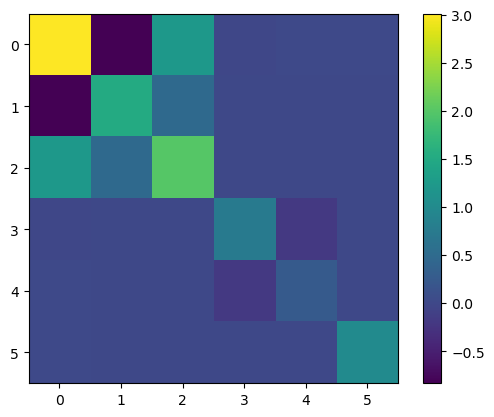

In [25]:
plt.imshow(covariance_matrix)
plt.colorbar()

<Axes: >

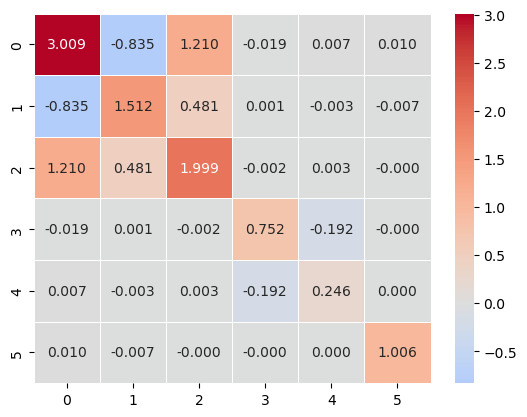

In [26]:
# or with some more fancy plotting, using the seaborn library
import seaborn as sns
sns.heatmap(covariance_matrix, annot=True, fmt=".3f", cmap="coolwarm", linewidths=0.5, linecolor='white', center=0)

Now we can compute the correlation matrix:

In [47]:
std_features = X.std()
std_features

temperature            1.734621
pression               1.229628
position               1.413894
speed                  0.867398
acceleration           0.496087
number_of_particles    1.002895
dtype: float64

To compute the denominator for the correlation matrix we can use the matrix moltiplication syntax from numpy:

$$ corr(x_1,x_2) = \frac{cov(x_1,x_2)}{\sqrt{var(x_1)*var(x_2)}}$$

In [48]:
np.expand_dims(std_features, 1)

array([[1.73462064],
       [1.22962838],
       [1.41389402],
       [0.86739828],
       [0.49608683],
       [1.00289466]])

In [49]:
var_denom = np.expand_dims(std_features, 1) @ np.expand_dims(std_features, 0)
var_denom

array([[3.00890875, 2.13293877, 2.45256975, 1.50460695, 0.86052246,
        1.73964177],
       [2.13293877, 1.51198596, 1.73856422, 1.06657754, 0.61000245,
        1.23318773],
       [2.45256975, 1.73856422, 1.99909631, 1.22640924, 0.70141421,
        1.41798676],
       [1.50460695, 1.06657754, 1.22640924, 0.75237977, 0.43030486,
        0.8699091 ],
       [0.86052246, 0.61000245, 0.70141421, 0.43030486, 0.24610214,
        0.49752283],
       [1.73964177, 1.23318773, 1.41798676, 0.8699091 , 0.49752283,
        1.00579769]])

In [50]:
corr = covariance_matrix / var_denom
corr

array([[ 1.00000000e+00, -3.91623381e-01,  4.93330957e-01,
        -1.27353198e-02,  7.88405304e-03,  5.72995748e-03],
       [-3.91623381e-01,  1.00000000e+00,  2.76695118e-01,
         1.34001418e-03, -5.56658344e-03, -5.28085973e-03],
       [ 4.93330957e-01,  2.76695118e-01,  1.00000000e+00,
        -1.37706288e-03,  4.36400523e-03, -3.32675692e-04],
       [-1.27353198e-02,  1.34001418e-03, -1.37706288e-03,
         1.00000000e+00, -4.46946242e-01, -6.50639181e-05],
       [ 7.88405304e-03, -5.56658344e-03,  4.36400523e-03,
        -4.46946242e-01,  1.00000000e+00,  8.93934059e-04],
       [ 5.72995748e-03, -5.28085973e-03, -3.32675692e-04,
        -6.50639181e-05,  8.93934059e-04,  1.00000000e+00]])

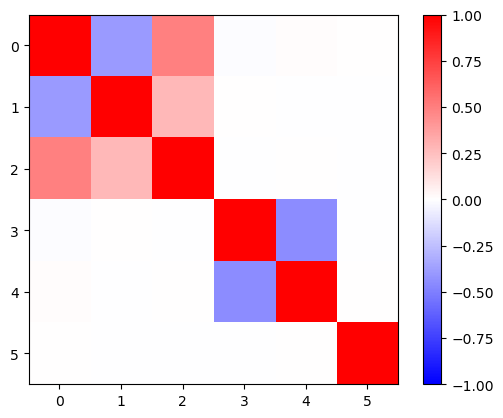

In [51]:
plt.imshow(corr, cmap="bwr", vmin=-1, vmax=1)
plt.colorbar()

# 4) Histogramming

Histograms are tools to estimate a probability density function when samples or "observations" are available. 
In this next part of the exercise you will analyze the dataset by plotting histograms of each measurement feature and also by checking their corrections with 2D histograms.

1) Draw the 1D histogram of all the features in the dataset
2) Draw the 2D histograms of pairs of features.
3) (Bonus) You can  plot then as a "corner" plot, look [here](https://corner.readthedocs.io/en/latest/pages/quickstart/) to take inspiration.

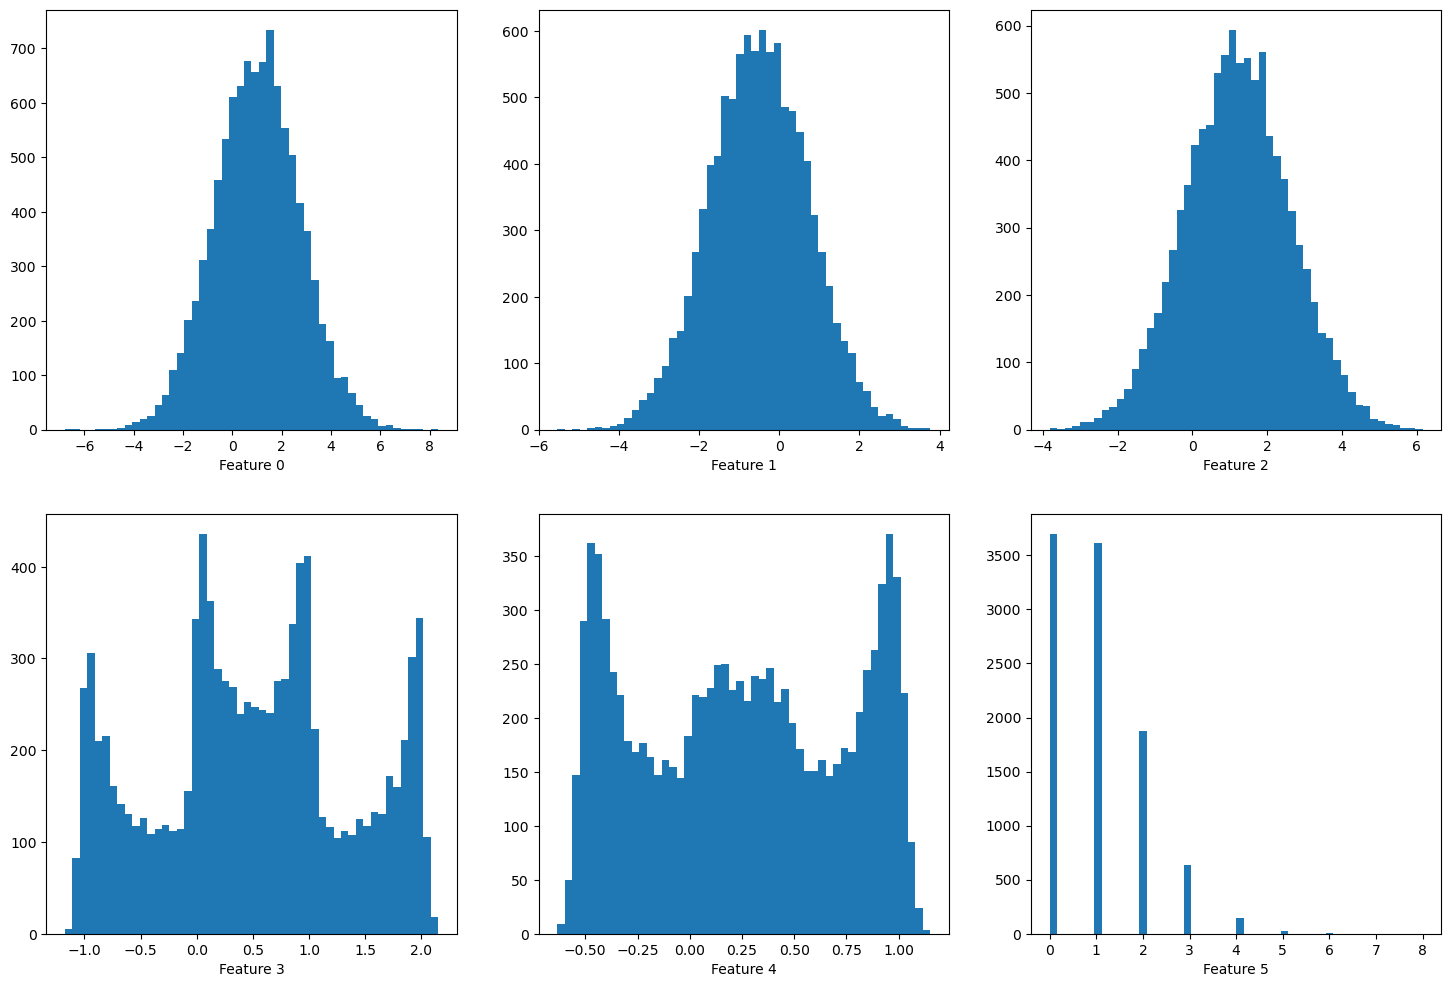

In [55]:
f, axs = plt.subplots(2, 3, figsize=(18,12), dpi=100)

for i, icol in enumerate(columns):
    x = X[icol]
    axs[i//3, i%3].hist(x, bins=50)
    axs[i//3, i%3].set_xlabel(f"Feature {i}")

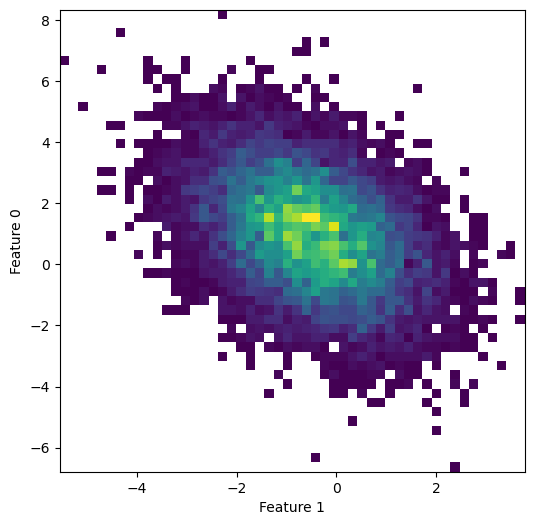

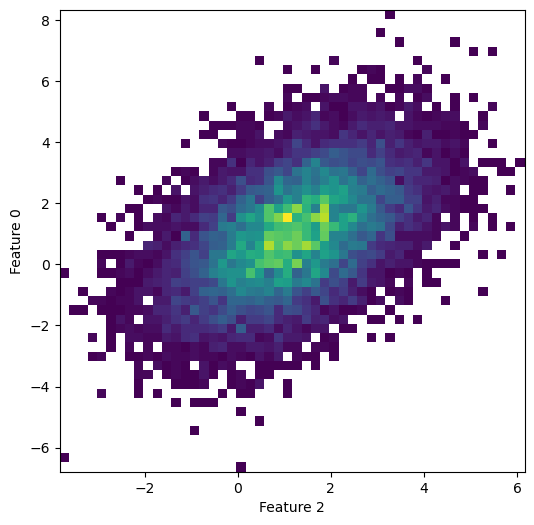

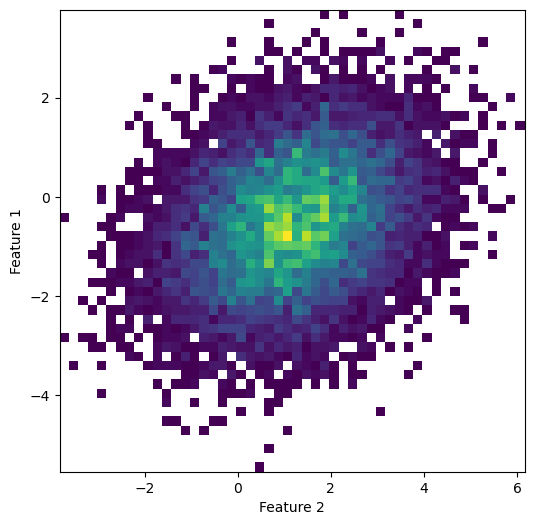

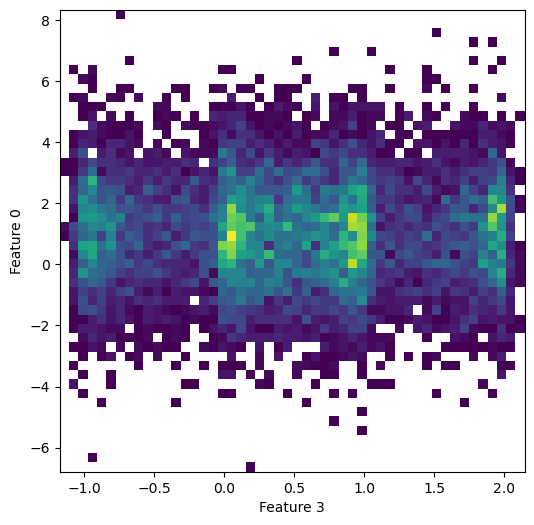

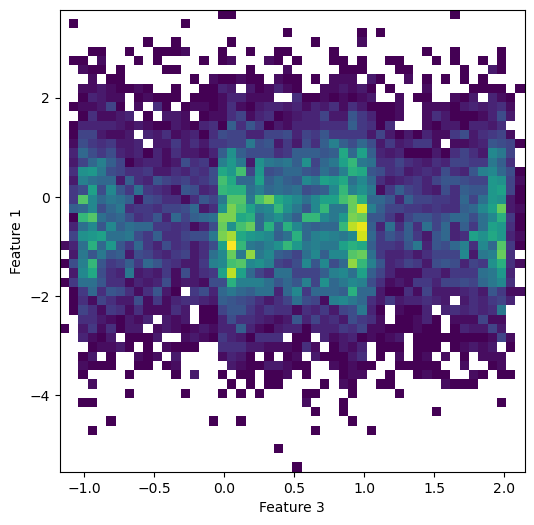

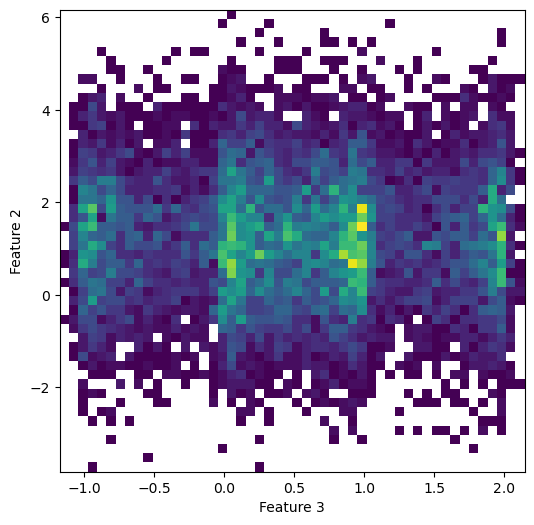

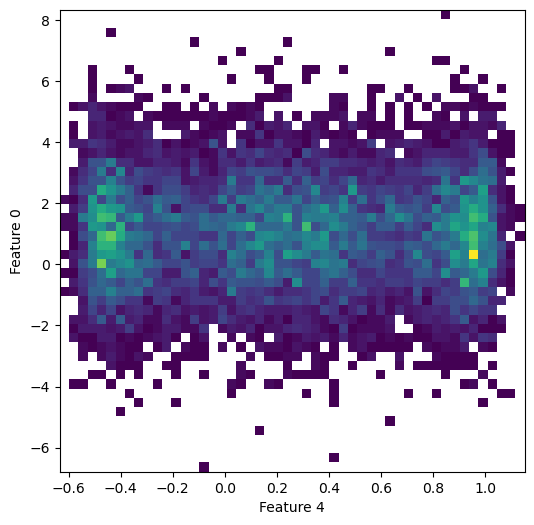

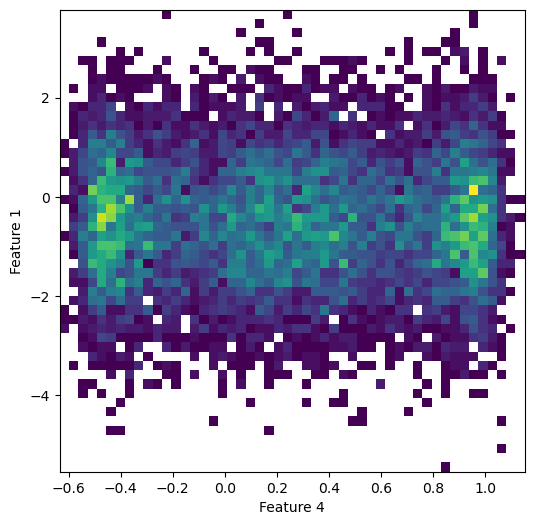

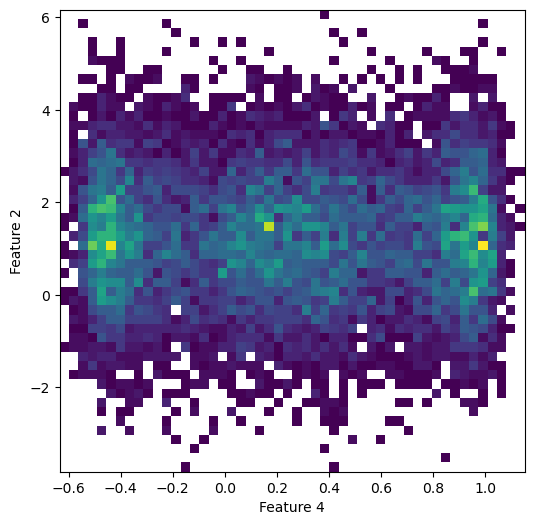

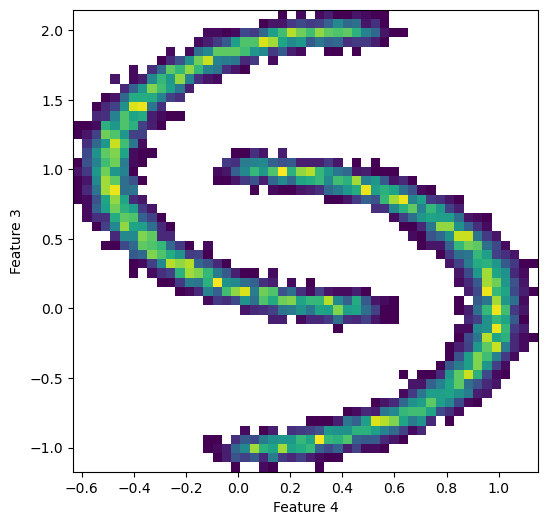

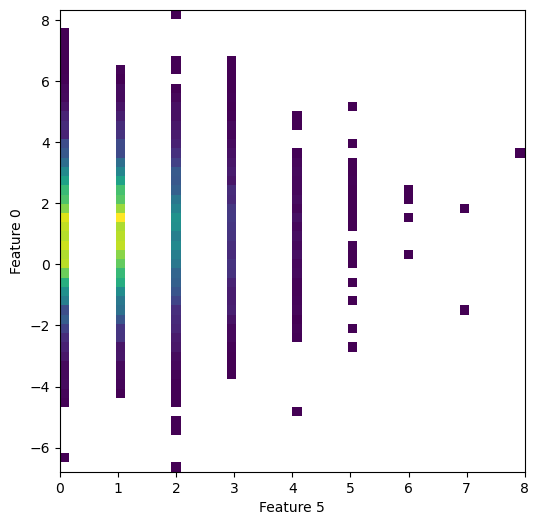

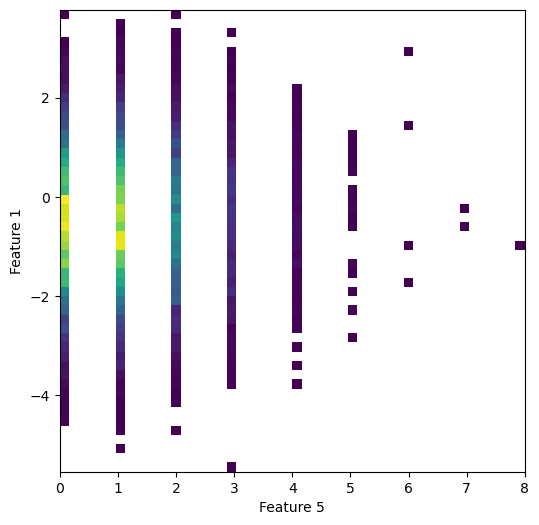

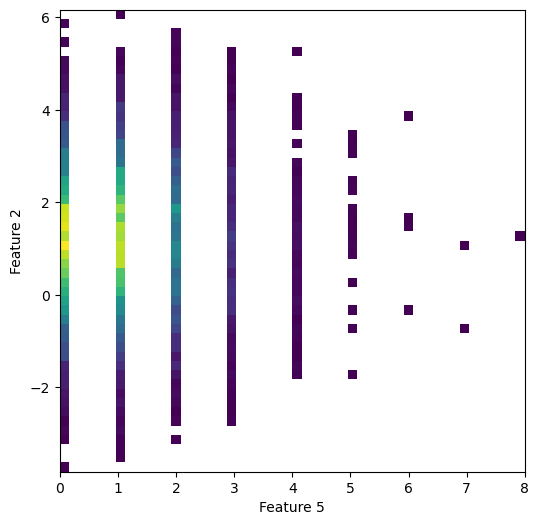

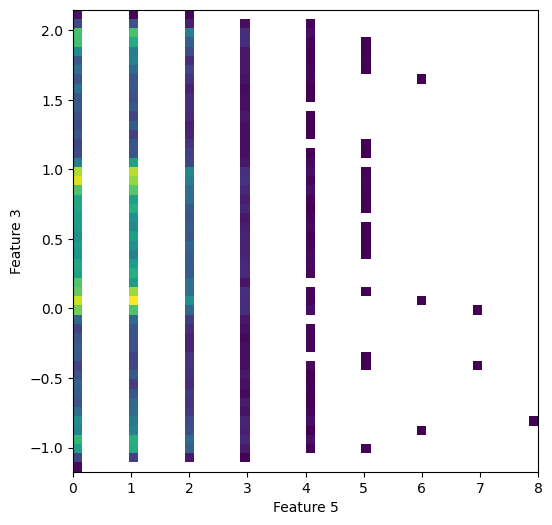

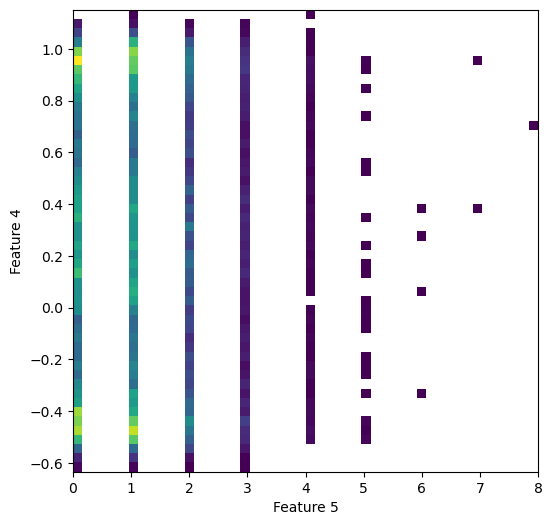

In [57]:
for i, icol in enumerate(columns):
    for j, jcol in enumerate(columns):
        if j>=i: continue
        x = X[icol]
        y = X[jcol]
        f = plt.figure(figsize=(6,6))
        plt.hist2d(x, y, bins=50, cmap="viridis", cmin=1)
        plt.xlabel(f"Feature {i}")
        plt.ylabel(f"Feature {j}")
        plt.show()

### Bonus
Corner plot

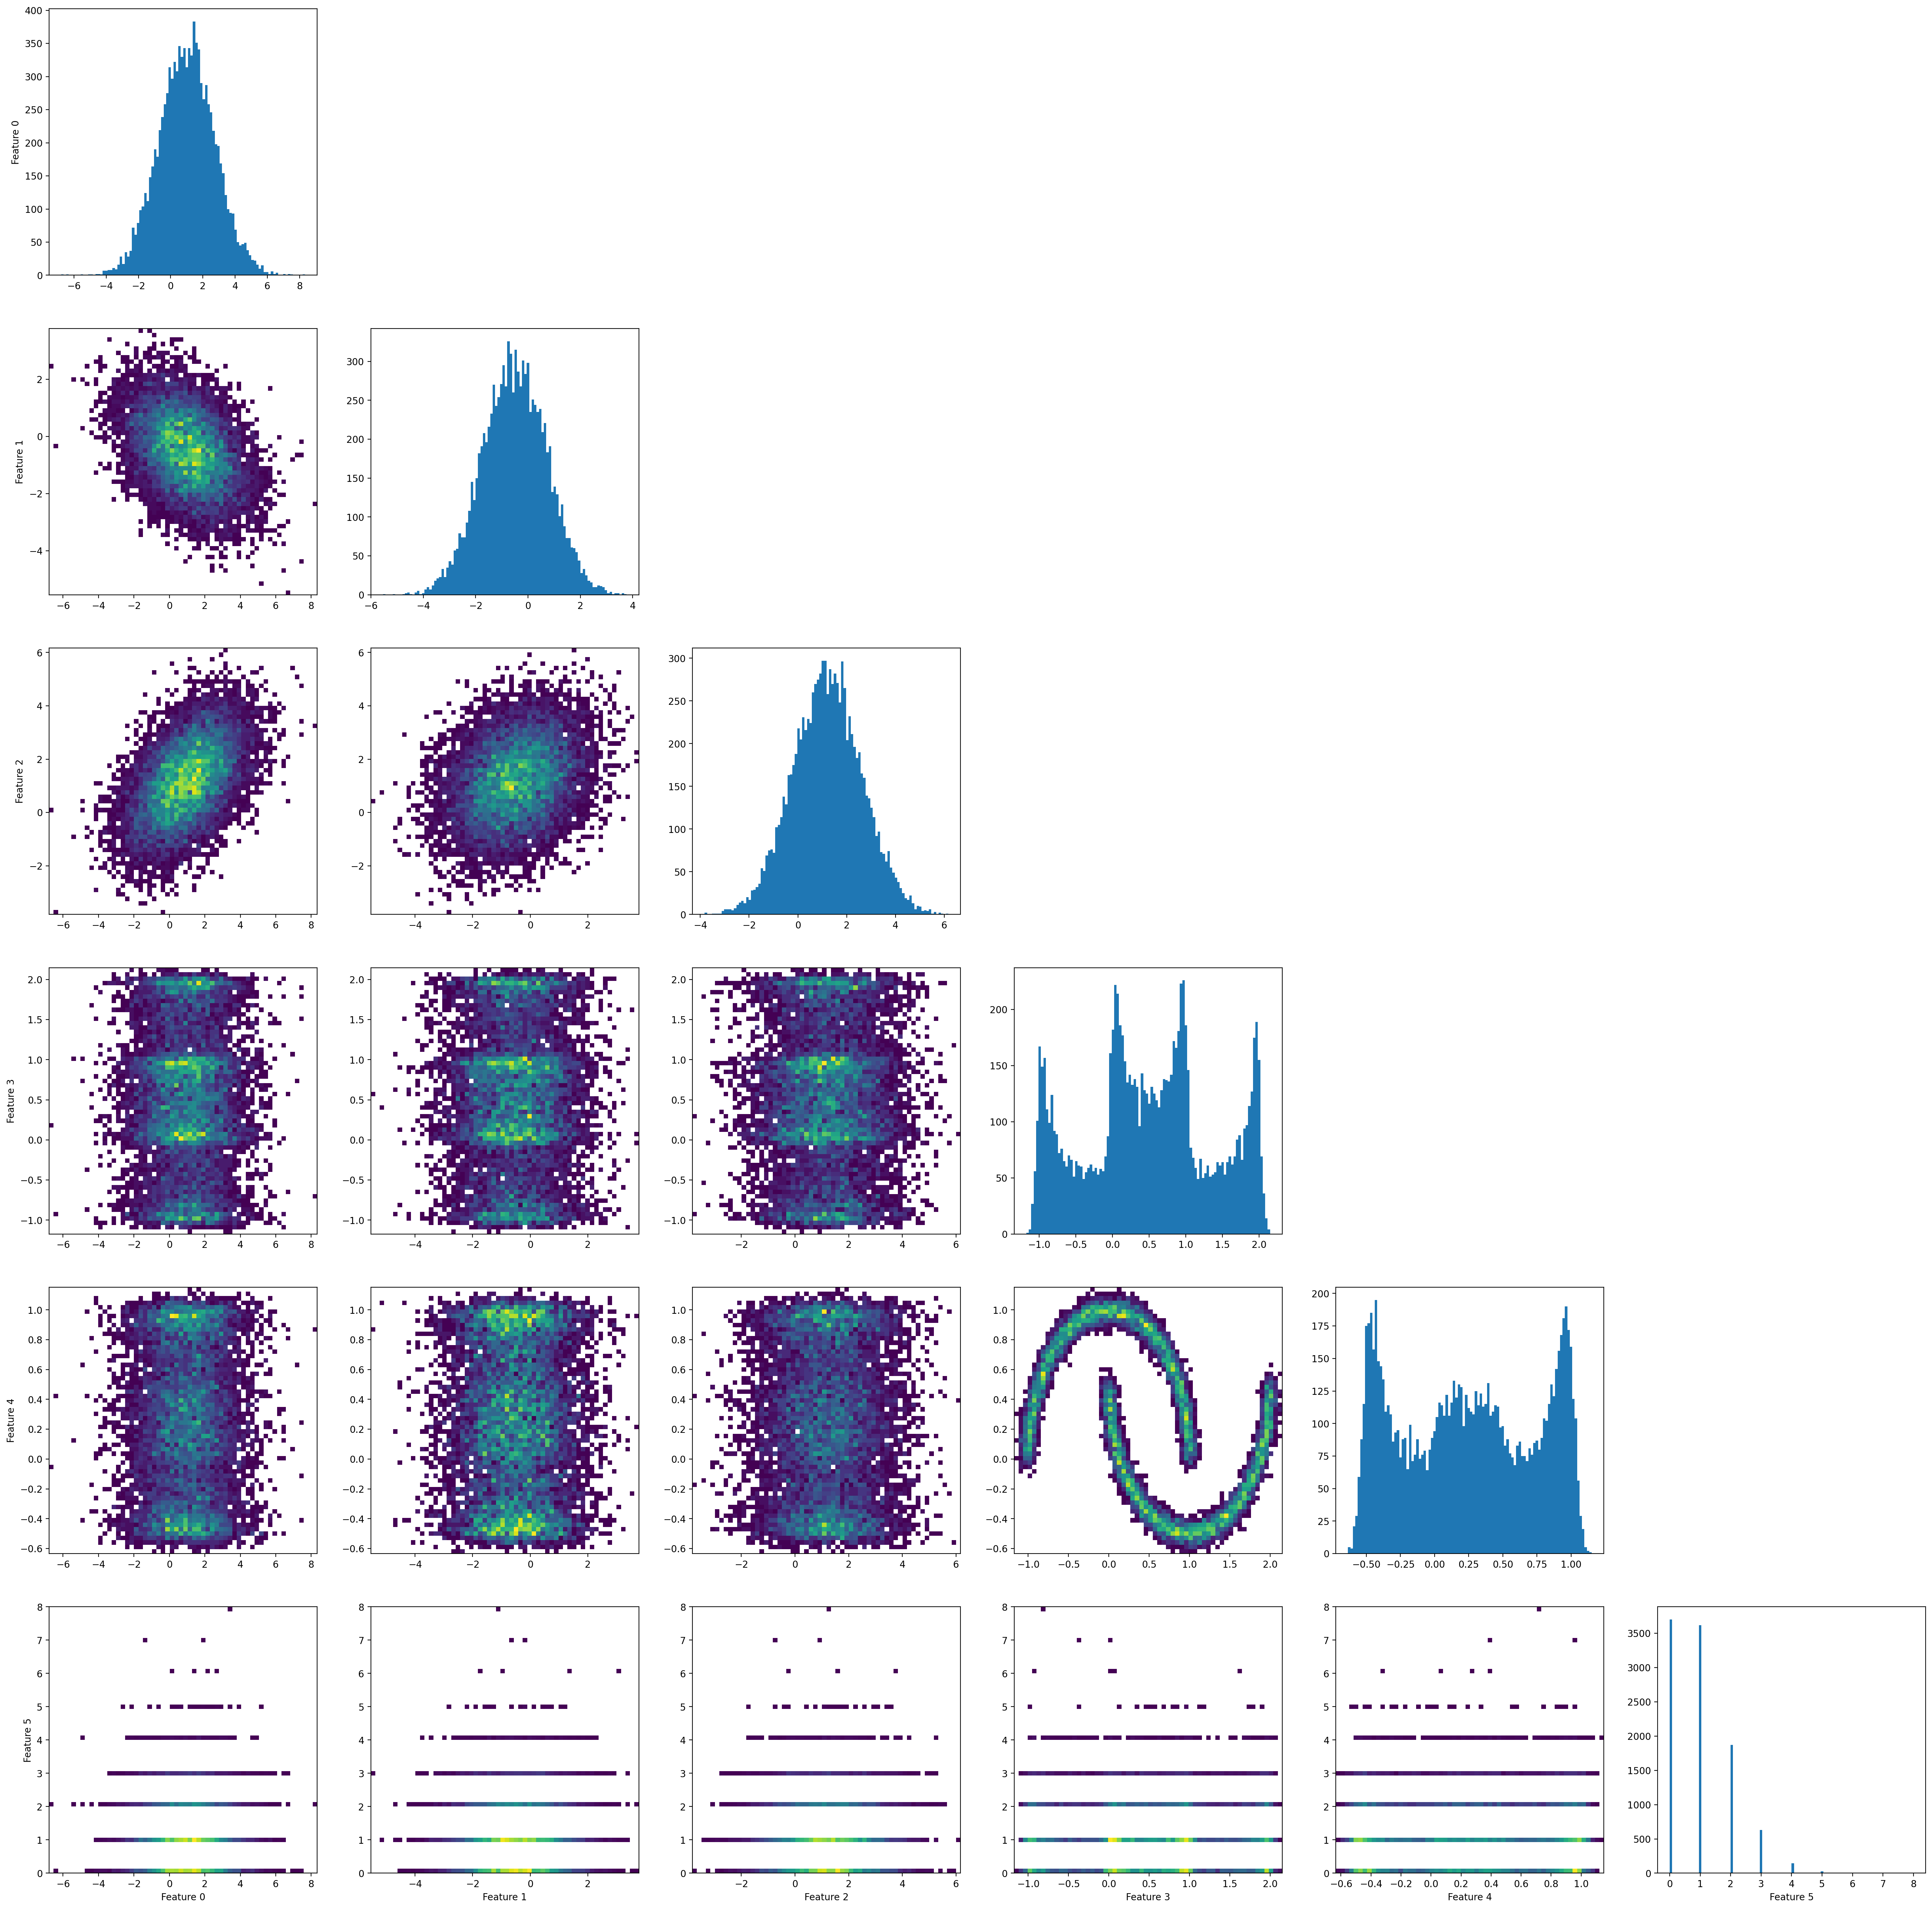

In [58]:
f, axs = plt.subplots(6,6, figsize=(36, 36), dpi=200)

for i, icol in enumerate(columns):
    for j, jcol in enumerate(columns):
        x = X[icol]
        y = X[jcol]
        if i == j:
            axs[i][j].hist(x, bins=100)
            if j == 5:
                axs[i][j].set_xlabel(f"Feature {i}")
            if i == 0:
                axs[i][j].set_ylabel(f"Feature {i}")
        elif j>i:
            axs[i][j].remove()
        else:
            axs[i][j].hist2d(y, x, bins=60, cmap="viridis", cmin=1)
            if i == 5:
                axs[i][j].set_xlabel(f"Feature {j}")
            if j == 0:
                axs[i][j].set_ylabel(f"Feature {i}")